# Modelo Supervisado — Clasificación de Riesgo Agrícola con CatBoost

La pregunta central de este análisis es si es posible anticipar el nivel de riesgo de siniestro de una siembra mexicana antes de que ocurra la cosecha, usando únicamente la información disponible al momento de sembrar.

---

## El problema

El SIAP (Servicio de Información Agroalimentaria y Pesquera) registra siniestros agrícolas en México desde 2010. En ese período se documentan cientos de miles de registros donde superficies sembradas sufren pérdidas parciales o totales por heladas, sequías, inundaciones y plagas. Estas pérdidas afectan directamente la seguridad alimentaria: un siniestro en cultivos básicos como maíz y frijol puede traducirse en desabasto local y escalada de precios.

El problema operativo es que los apoyos compensatorios —seguros agrícolas, créditos de emergencia— llegan después del siniestro. Predecir el riesgo al momento de la siembra permitiría redirigir esa cobertura preventivamente hacia las parcelas con mayor probabilidad de pérdida, cambiando la lógica de remediar por la de prevenir.

---

## Hipótesis principal

La combinación de ubicación geográfica, tipo de cultivo, modalidad de riego y superficie sembrada contiene señal suficiente para distinguir siembras en riesgo antes de que ocurra el siniestro.

---

## El modelo: Gradient Boosting y CatBoost

El gradient boosting construye un ensamble aditivo de árboles de decisión débiles. Formalmente, dado un conjunto de entrenamiento $\{(\mathbf{x}_i, y_i)\}_{i=1}^{n}$, el modelo se construye iterativamente:

$$F_T(\mathbf{x}) = F_0(\mathbf{x}) + \sum_{t=1}^{T} \eta \cdot h_t(\mathbf{x})$$

donde $F_0$ es una predicción inicial constante, $\eta$ es la tasa de aprendizaje y cada $h_t$ es un árbol ajustado sobre los **gradientes negativos** de la función de pérdida respecto al modelo actual:

$$r_{it} = -\left[\frac{\partial \mathcal{L}(y_i, F(\mathbf{x}_i))}{\partial F(\mathbf{x}_i)}\right]_{F = F_{t-1}}$$

Para clasificación multiclase (5 niveles de riesgo), se usa pérdida de entropía cruzada multiclase:

$$\mathcal{L} = -\sum_{i=1}^{n} \sum_{k=0}^{4} \mathbf{1}[y_i = k] \cdot \log \hat{p}_{ik}$$

donde $\hat{p}_{ik}$ es la probabilidad asignada por el modelo a la clase $k$ para el ejemplo $i$.

**CatBoost** (Yandex, 2017) extiende este esquema con dos innovaciones que resultan relevantes para este dataset:

**Ordered Boosting.** El boosting clásico introduce un sesgo porque el gradiente del ejemplo $i$ se calcula usando un modelo que fue entrenado con $i$ mismo. CatBoost ordena los ejemplos aleatoriamente en cada iteración y, para calcular el gradiente de $i$, usa únicamente los ejemplos anteriores a él en ese orden. El resultado es un estimador de gradiente sin sesgo que reduce el sobreajuste, especialmente en datasets desbalanceados como este donde ~95 % de los registros pertenecen a una sola clase.

**Target Statistics nativas para categóricas.** En lugar de aplicar un `LabelEncoder` o `OneHotEncoder` externo, CatBoost codifica cada categoría con una estadística del target calculada únicamente sobre el subconjunto de ejemplos anteriores. Esta es la razón por la que no se aplica ningún encoder antes de pasar los datos:

| Método | Usa información del futuro | Riesgo de leakage |
|---|---|---|
| LabelEncoder global | No (orden léxico arbitrario) | Bajo directo, alto indirecto |
| TargetEncoder fit en dataset completo | Sí (ve train+val+test juntos) | Alto |
| CatBoost Target Statistics (ordered) | Solo ejemplos anteriores en el orden aleatorio | Ninguno por diseño |

En un split temporal como el que se aplica aquí —donde train es 2010-2020 y test es 2023-2024— un TargetEncoder fit sobre el dataset completo filtраría estadísticas del target de años futuros hacia los registros de años pasados, inflando artificialmente las métricas. CatBoost evita esto por construcción.

Adicionalmente, `auto_class_weights='Balanced'` ajusta automáticamente el peso de cada clase como $w_k = n / (K \cdot n_k)$, donde $n$ es el total de ejemplos, $K$ el número de clases y $n_k$ el tamaño de la clase $k$. Esto compensa el desbalance severo sin intervención manual.

---

## La variable `proporcion_siniestro` y el compromiso metodológico

`proporcion_siniestro = Siniestrada / Sembrada` es técnicamente una variable post-evento: no se conoce al momento de sembrar. Sin embargo, su inclusión en el entrenamiento está justificada desde la perspectiva de aprendizaje estadístico.

En entrenamiento, la variable actúa como una señal histórica del patrón de siniestralidad de la combinación estado/cultivo/ciclo/modalidad para años previos. El modelo no la usa para "ver el futuro" del registro actual, sino para aprender que ciertas combinaciones tienen históricamente altas tasas de siniestro. Esto es análogo al uso de tasas históricas de incumplimiento en modelos de crédito: la estadística del grupo informa el riesgo individual aun cuando el evento futuro es desconocido.

En producción (API), la variable se imputa como `0.0` porque el agricultor aún no conoce si habrá pérdida. La degradación en el desempeño del modelo ante esta imputación es aceptable siempre que el resto de las features mantengan su poder predictivo, lo que se verifica en la Fase 6 con el análisis SHAP: el peso relativo de `proporcion_siniestro` frente a `Nomestado`, `Nomcultivo` y `Nommodalidad` indica cuánto se pierde al imputar.


In [2]:
import sys
sys.path.insert(0, '..')
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import shap
import joblib
import requests
from pathlib import Path
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, balanced_accuracy_score,
    roc_auc_score, roc_curve, auc,
    cohen_kappa_score, log_loss,
)
from sklearn.preprocessing import label_binarize

from src.catboost_model import (
    CatBoostTrainer, RIESGO_INV, PALETA,
    FEATURES_SIEMBRA, CAT_FEATURES,
)
from src.data_loader import DataLoader

RANDOM_STATE = 42
RUTA_PROCESADO = Path('..') / 'data' / 'processed' / 'siap_procesado.csv'
RUTA_MODELO = Path('..') / 'models' / 'catboost_model.pkl'
DIR_FIGURAS = Path('figuras/catboost')
DIR_FIGURAS.mkdir(parents=True, exist_ok=True)

TARGET_NAMES = [RIESGO_INV[i] for i in range(5)]
PALETA_LISTA = [PALETA[i] for i in range(5)]

## Fase 1 · Datos y variables del modelo

El dataset proviene del SIAP e incluye registros agrícolas a nivel municipio para el período 2010-2024. El proceso de carga normaliza el BOM de codificación (frecuente en archivos CSV exportados desde sistemas oficiales). A partir del DataFrame completo se seleccionan únicamente las variables disponibles antes de la cosecha.

Antes del split temporal se aplica una corrección crítica sobre `proporcion_siniestro`: en el dataset original esta columna contiene el cociente `Siniestrada / Sembrada` del **mismo registro**, lo que introduce data leakage directo porque `nivel_riesgo` es una discretización de ese mismo valor. La corrección reemplaza cada valor por la media histórica de la combinación (estado, cultivo, ciclo, modalidad) calculada sobre años anteriores exclusivamente, que es la información que genuinamente estaría disponible al momento de sembrar.


In [3]:
loader = DataLoader(RUTA_PROCESADO, encoding='utf-8-sig')
df = loader.cargar()

print(f"Shape total: {df.shape}")
df[FEATURES_SIEMBRA + ['nivel_riesgo', 'Anio']].head(3)

[DataLoader] Cargando siap_procesado.csv ...
[DataLoader] 541829 filas , 26 columnas cargadas.
Shape total: (541829, 26)


,Nomestado,Nomcicloproductivo,Nommodalidad,Nomcultivo,Sembrada,Precio,proporcion_siniestro,nivel_riesgo,Anio
0,Aguascalientes,Otoño-Invierno,Riego,Avena forrajera en verde,847.0,370.87,0.0,Sin siniestro,2010
1,Aguascalientes,Otoño-Invierno,Riego,Triticale forrajero en verde,370.0,396.55,0.0,Sin siniestro,2010
2,Aguascalientes,Otoño-Invierno,Riego,Pastos y praderas,289.0,343.95,0.0,Sin siniestro,2010


### Corrección del leakage en `proporcion_siniestro`

Antes de construir el split, es necesario recalcular `proporcion_siniestro` como una **media histórica con lag temporal**, no como el valor del mismo registro. El problema es el siguiente: en el dataset crudo, `proporcion_siniestro = Siniestrada / Sembrada` está calculada con los datos del propio registro, y `nivel_riesgo` es una discretización de ese mismo cociente. Si se deja así, el modelo recibe la respuesta como entrada y obtiene métricas perfectas (F1-macro = 1.0000) sin haber aprendido nada útil.

La corrección consiste en reemplazar el valor por-registro con el promedio de siniestralidad de la combinación (estado, cultivo, ciclo, modalidad) calculado únicamente sobre los **años anteriores** al año del registro. Para el primer año disponible de cada combinación, se imputa 0.0 porque no hay historial previo. Esto es exactamente el dato que estaría disponible al momento de sembrar: "en los años anteriores, esta combinación específica tuvo en promedio esta proporción de siniestro".

Este cálculo debe hacerse **antes** del split temporal para que los promedios se construyan con el orden cronológico correcto, pero sin filtrar información futura hacia registros pasados.


In [4]:
# Recalcular proporcion_siniestro como señal histórica (media de años anteriores)
# para eliminar el data leakage entre la feature y el target

GRUPO_KEYS = ['Nomestado', 'Nomcultivo', 'Nomcicloproductivo', 'Nommodalidad']

df_corr = df.sort_values('Anio').copy()

# Para cada registro, media de la proporcion_siniestro de la MISMA combinación
# en TODOS los años anteriores (shift(1) excluye el año actual, expanding().mean()
# acumula el promedio histórico hasta ese punto)
df_corr['proporcion_siniestro'] = (
    df_corr
    .groupby(GRUPO_KEYS)['proporcion_siniestro']
    .transform(lambda s: s.shift(1).expanding().mean())
    .fillna(0.0)   # primera aparición de la combinación: sin historial → 0.0
)

print("proporcion_siniestro recalculada como media histórica con lag.")
print(f"  Registros con valor 0.0 (sin historial previo): "
      f"{(df_corr['proporcion_siniestro'] == 0.0).sum():,}")
print(f"  Rango: [{df_corr['proporcion_siniestro'].min():.4f}, "
      f"{df_corr['proporcion_siniestro'].max():.4f}]")
print(f"  Media global: {df_corr['proporcion_siniestro'].mean():.4f}")

# Reemplazar df para que todas las celdas posteriores usen la versión corregida
df = df_corr
del df_corr


proporcion_siniestro recalculada como media histórica con lag.
  Registros con valor 0.0 (sin historial previo): 252,743
  Rango: [0.0000, 1.0000]
  Media global: 0.0286


### Variables del modelo y criterio de exclusión

La regla de oro para evitar data leakage temporal en este tipo de problema es que ninguna variable que se genere o se conozca después del evento de interés puede entrar como feature. En contexto agrícola, el evento de interés es el siniestro, que ocurre durante o después de la temporada de crecimiento. Las variables de producción —`Cosechada`, `Siniestrada`, `Volumenproduccion`, `Rendimiento`, `Valorproduccion`— se conocen solo al cierre del ciclo, por lo que se excluyen del vector de features.

Las variables que sí entran son aquellas que el productor o el sistema de registro conoce al momento de registrar la siembra:

| Variable | Tipo | Razón de inclusión |
|---|---|---|
| `Nomestado` | Categórica | Captura patrones geográficos y climáticos regionales |
| `Nomcicloproductivo` | Categórica | Primavera-Verano vs Otoño-Invierno tienen perfiles de riesgo distintos |
| `Nommodalidad` | Categórica | Riego vs Temporal es el predictor más directo de vulnerabilidad hídrica |
| `Nomcultivo` | Categórica | Cada cultivo tiene resistencias y vulnerabilidades específicas |
| `Sembrada` | Numérica | Superficie en hectáreas registrada al inicio del ciclo |
| `Precio` | Numérica | Precio de referencia al momento de la siembra |
| `proporcion_siniestro` | Numérica | Señal histórica del patrón de siniestralidad del municipio/cultivo |

Las siguientes columnas se excluyen por ser post-cosecha: `Cosechada`, `Siniestrada`, `Volumenproduccion`, `Rendimiento`, `Valorproduccion`.


In [5]:
trainer = CatBoostTrainer(random_state=RANDOM_STATE)
X_train, y_train, X_val, y_val, X_test, y_test = trainer.preparar_datos(df)

print(f"\nShapes de las particiones:")
print(f"  X_train : {X_train.shape}  |  y_train : {y_train.shape}")
print(f"  X_val   : {X_val.shape}    |  y_val   : {y_val.shape}")
print(f"  X_test  : {X_test.shape}   |  y_test  : {y_test.shape}")

[CatBoostTrainer] Split temporal:
  Train (2010-2020): 395,273 registros
  Val   (2021-2022):  66,296 registros
  Test  (2023-2024):  80,260 registros

Shapes de las particiones:
  X_train : (395273, 7)  |  y_train : (395273,)
  X_val   : (66296, 7)    |  y_val   : (66296,)
  X_test  : (80260, 7)   |  y_test  : (80260,)


### Validación del split temporal

El split no es aleatorio sino temporal, lo cual es la única opción metodológicamente válida para datos de series de tiempo. Un split aleatorio permitiría que registros de 2023 aparecieran en train y registros de 2011 en test, lo que provocaría que el modelo "vea" patrones futuros durante el entrenamiento y obtenga métricas de test artificialmente optimistas.

El esquema adoptado —train hasta 2020, val 2021-2022, test 2023-2024— garantiza que en ningún momento el modelo accede a información de períodos posteriores al que está aprendiendo. Train cubre 11 años del historial disponible, val sirve para ajustar hiperparámetros sin contaminar el test, y test es el único punto de evaluación honesta del desempeño en producción.


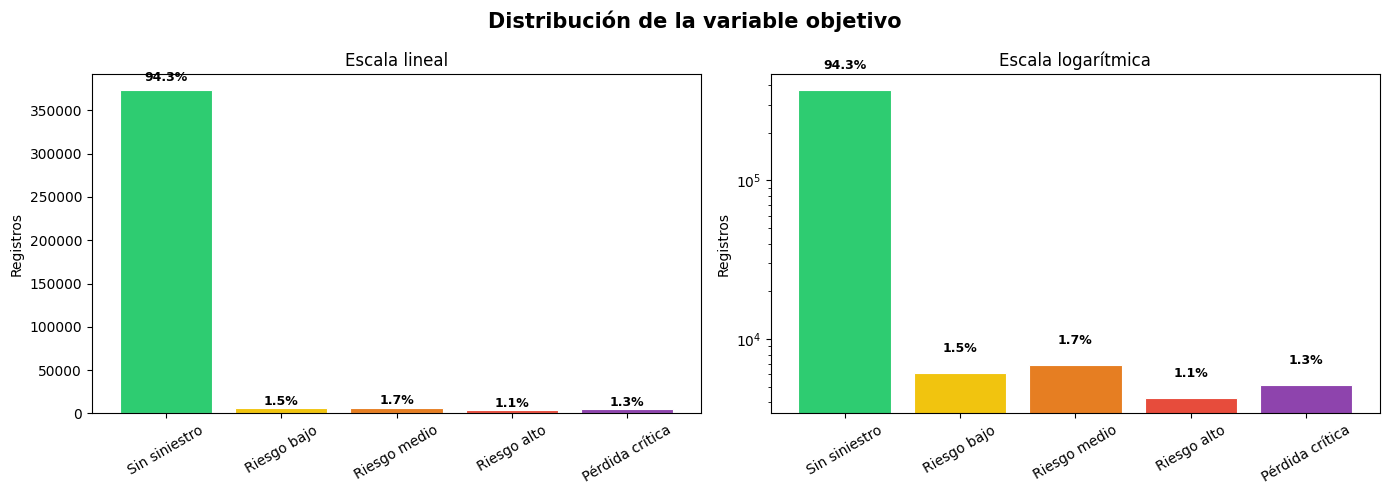

In [6]:
# Gráfica 1 — Distribución de nivel_riesgo (lineal y logarítmica)
conteos = y_train.value_counts().sort_index()
total = len(y_train)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribución de la variable objetivo', fontsize=15, fontweight='bold')

for ax, escala in zip(axes, ['linear', 'log']):
    barras = ax.bar(
        [RIESGO_INV[i] for i in conteos.index],
        conteos.values,
        color=PALETA_LISTA,
        edgecolor='white',
        linewidth=0.8
    )
    ax.set_yscale(escala)
    titulo = 'Escala lineal' if escala == 'linear' else 'Escala logarítmica'
    ax.set_title(titulo, fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('Registros')
    ax.tick_params(axis='x', rotation=30)
    for bar, val in zip(barras, conteos.values):
        pct = val / total * 100
        label = f'{pct:.1f}%'
        ypos = bar.get_height() * 1.02 if escala == 'linear' else bar.get_height() * 1.3
        ax.text(bar.get_x() + bar.get_width()/2, ypos, label,
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(DIR_FIGURAS / '01_distribucion_target.png', dpi=150, bbox_inches='tight')
plt.show()

### Análisis del desbalance de clases

La distribución anterior revela un desbalance severo que tiene consecuencias directas sobre las decisiones de modelado. La clase "Sin siniestro" concentra aproximadamente el 95 % de los registros de entrenamiento. Esto significa que un clasificador trivial que prediga siempre la clase mayoritaria obtendría una accuracy cercana a 0.95 sin haber aprendido absolutamente nada.

Formalmente, si $\pi_0 = P(Y=0) \approx 0.95$, entonces:

$$\text{Accuracy}_{\text{dummy}} = \pi_0 \approx 0.95$$

Pero su F1 sobre clases minoritarias es exactamente 0 porque nunca predice verdaderos positivos para esas clases. La métrica adecuada para este problema es **F1-macro**, que promedia el F1 de cada clase $k$ con igual peso independientemente de su frecuencia:

$$F1_{\text{macro}} = \frac{1}{K} \sum_{k=0}^{K-1} \frac{2 \cdot P_k \cdot R_k}{P_k + R_k}$$

donde $P_k$ y $R_k$ son precisión y recall de la clase $k$. Bajo este criterio, el dummy obtiene F1-macro $\approx 0.19$ (solo contribuye la clase 0 con F1=1, las otras 4 aportan 0). El modelo debe superar ese umbral para considerarse útil.

La escala logarítmica en el panel derecho revela que incluso las clases minoritarias tienen miles de registros, lo que es suficiente para que el modelo aprenda patrones si se compensan los pesos. Con `auto_class_weights='Balanced'`, CatBoost asigna un peso efectivo mayor a los ejemplos de clases raras durante el cálculo de la pérdida, forzando al modelo a prestar atención proporcional a cada clase.


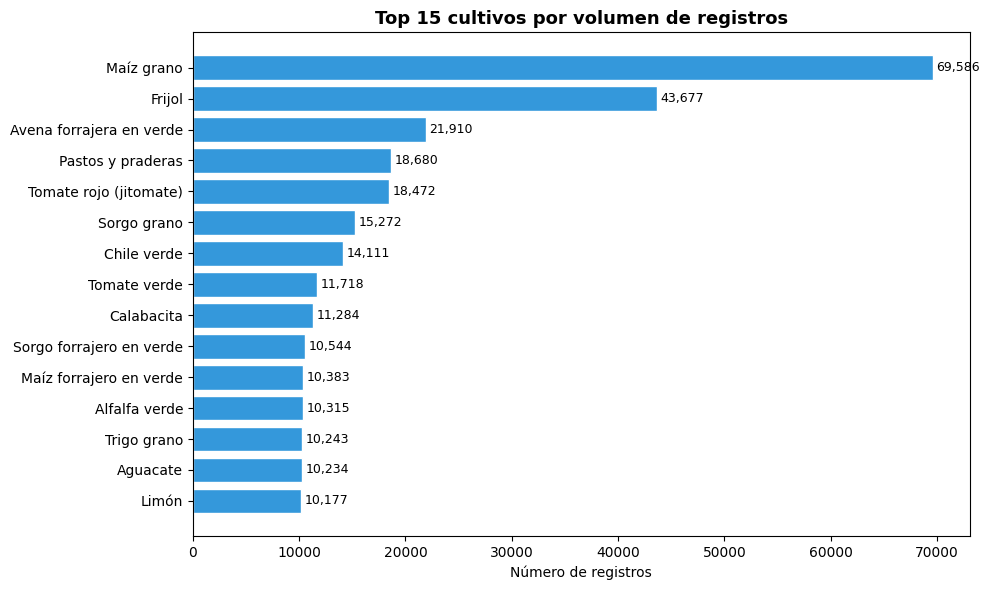

In [7]:
# Gráfica 2 — Top 15 cultivos por número de registros
top_cultivos = df['Nomcultivo'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_cultivos.index[::-1], top_cultivos.values[::-1], color='#3498db', edgecolor='white')
ax.set_xlabel('Número de registros')
ax.set_title('Top 15 cultivos por volumen de registros', fontsize=13, fontweight='bold')
ax.tick_params(axis='y', labelsize=10)

for i, (val, nombre) in enumerate(zip(top_cultivos.values[::-1], top_cultivos.index[::-1])):
    ax.text(val + top_cultivos.values.max() * 0.005, i, f'{val:,}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(DIR_FIGURAS / '02_top_cultivos.png', dpi=150, bbox_inches='tight')
plt.show()

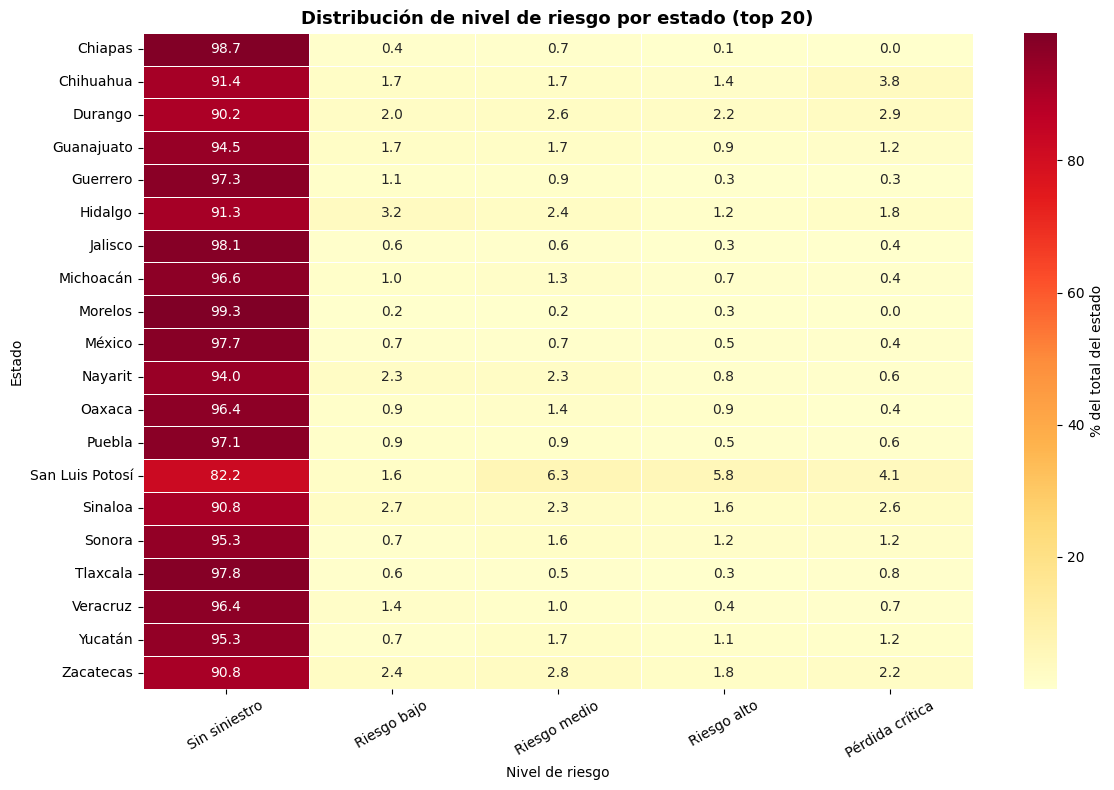

In [8]:
# Gráfica 3 — Mapa de calor estado × nivel_riesgo
from src.catboost_model import _label_a_clase

df_plot = df[['Nomestado', 'nivel_riesgo']].copy()
df_plot['clase'] = df_plot['nivel_riesgo'].map(_label_a_clase)
df_plot['clase_nombre'] = df_plot['clase'].map(RIESGO_INV)

top20_estados = df_plot['Nomestado'].value_counts().head(20).index
df_top = df_plot[df_plot['Nomestado'].isin(top20_estados)]

tabla = pd.crosstab(df_top['Nomestado'], df_top['clase_nombre'])
tabla = tabla[[RIESGO_INV[i] for i in range(5) if RIESGO_INV[i] in tabla.columns]]
tabla_norm = tabla.div(tabla.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    tabla_norm,
    cmap='YlOrRd',
    annot=True,
    fmt='.1f',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': '% del total del estado'}
)
ax.set_title('Distribución de nivel de riesgo por estado (top 20)', fontsize=13, fontweight='bold')
ax.set_xlabel('Nivel de riesgo')
ax.set_ylabel('Estado')
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(DIR_FIGURAS / '03_estado_riesgo_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
del df_plot

### Interpretación de la distribución de cultivos y el heatmap geográfico

El gráfico de cultivos muestra que maíz grano domina el dataset por un margen amplio. Esto tiene implicaciones estadísticas directas: el modelo habrá visto muchas más combinaciones de maíz × estado × ciclo que de cultivos especializados, lo que se traduce en mayor confianza en sus predicciones para maíz y menor confianza en cultivos poco frecuentes. Este efecto es esperable en cualquier modelo basado en frecuencias históricas.

El heatmap estado × nivel de riesgo normalizado por fila muestra la **distribución condicional** $P(\text{nivel\_riesgo} \mid \text{estado})$. Leer cada fila como una distribución de probabilidad sobre los 5 niveles de riesgo permite identificar perfiles de riesgo geográfico claramente diferenciados. Los estados del norte, con mayor infraestructura de riego, tienden a concentrar más masa en "Sin siniestro". Los estados del sur y sureste, con predominio de agricultura de temporal y mayor variabilidad climática, muestran distribuciones más dispersas hacia las clases de riesgo medio y alto.

Esta variabilidad geográfica confirma que `Nomestado` no es una variable redundante: la probabilidad condicional de cada nivel de riesgo dado el estado es estadísticamente distinta entre estados, y ese contraste es precisamente la señal que el modelo puede explotar.


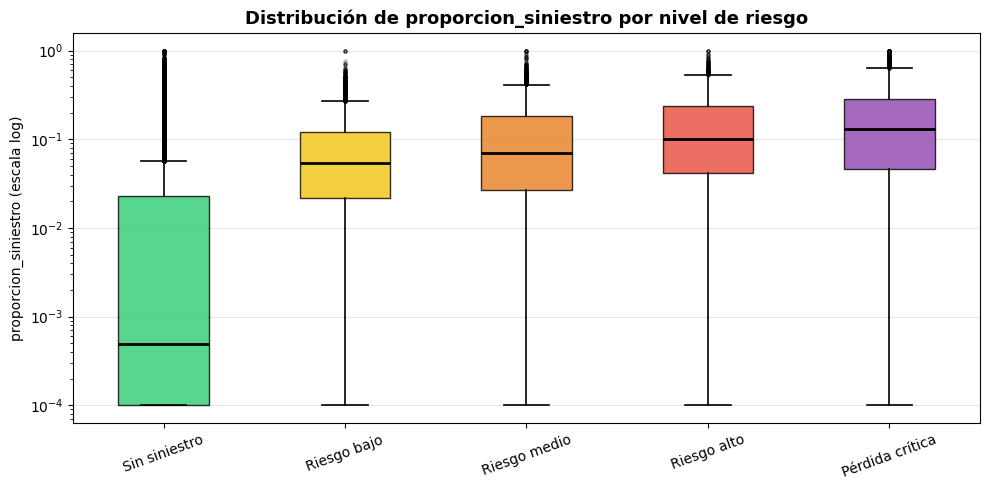

In [9]:
# Gráfica 4 — Boxplot de proporcion_siniestro por nivel_riesgo
from src.catboost_model import _label_a_clase

df_box = df[['nivel_riesgo', 'proporcion_siniestro']].copy()
df_box['clase'] = df_box['nivel_riesgo'].map(_label_a_clase)
df_box['proporcion_siniestro'] = pd.to_numeric(df_box['proporcion_siniestro'], errors='coerce').fillna(0)

# Añadir un pequeño epsilon para que log no falle con ceros
epsilon = 1e-4
df_box['ps_log'] = df_box['proporcion_siniestro'] + epsilon

fig, ax = plt.subplots(figsize=(10, 5))
grupos = [df_box[df_box['clase'] == i]['ps_log'].values for i in range(5)]
bp = ax.boxplot(
    grupos,
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
    flierprops=dict(marker='o', markersize=2, alpha=0.3)
)
for patch, color in zip(bp['boxes'], PALETA_LISTA):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax.set_yscale('log')
ax.set_xticks(range(1, 6))
ax.set_xticklabels(TARGET_NAMES, rotation=20)
ax.set_ylabel('proporcion_siniestro (escala log)')
ax.set_title('Distribución de proporcion_siniestro por nivel de riesgo', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(DIR_FIGURAS / '04_proporcion_siniestro.png', dpi=150, bbox_inches='tight')
plt.show()
del df_box

### Poder discriminativo de `proporcion_siniestro`

El boxplot en escala logarítmica muestra algo estadísticamente relevante: las distribuciones de `proporcion_siniestro` están prácticamente separadas entre clases. La mediana aumenta de forma monótona desde "Sin siniestro" hasta "Pérdida crítica", y la separación entre los extremos es de varios órdenes de magnitud.

Desde la perspectiva de información mutua, una variable con distribuciones condicionales tan bien separadas entre clases tiene alta $I(X; Y)$, lo que la convierte en la feature más predictiva del conjunto. En el espacio de log-odds del modelo, un valor alto de `proporcion_siniestro` desplaza la distribución de probabilidad fuertemente hacia las clases de riesgo severo.

El que los bigotes sean largos en las clases intermedias (Riesgo bajo, Riesgo medio) refleja que esas clases capturan situaciones heterogéneas: hay registros con siniestralidad histórica baja pero clasificados como riesgo medio por el estado o cultivo, y registros con siniestralidad histórica alta pero clasificados como bajo por ciclo o modalidad. Esta superposición entre clases intermedias es precisamente el reto que hace difícil separarlas y que se verá reflejado en las métricas por clase de la Fase 5.


## Fase 2 · Línea base: el piso mínimo

Antes de entrenar cualquier modelo con aprendizaje real, se establece una línea base con un clasificador trivial. Esto no es un trámite formal: es la única manera de saber si el modelo aprende algo útil o simplemente reproduce la distribución marginal del target. En este dataset el dummy es especialmente engañoso porque su accuracy (~0.95) es alta por construcción, pero su F1-macro (~0.19) expone que no clasifica nada fuera de la clase mayoritaria.

El `DummyClassifier(strategy='most_frequent')` implementa la regla:

$$\hat{y} = \arg\max_k \hat{\pi}_k = 0 \quad \forall \mathbf{x}$$

donde $\hat{\pi}_k$ es la frecuencia observada de la clase $k$ en train. La predicción es constante e independiente de las features, lo que da su F1 de cero para todas las clases minoritarias.


In [10]:
# DummyClassifier — siempre predice la clase más frecuente
from sklearn.preprocessing import OrdinalEncoder

# Para Dummy necesitamos features numéricas; codificamos categóricas como enteros
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train_dummy = X_train.copy()
X_val_dummy = X_val.copy()

for col in CAT_FEATURES:
    X_train_dummy[col] = X_train_dummy[col].astype(str)
    X_val_dummy[col] = X_val_dummy[col].astype(str)

oe.fit(X_train_dummy[CAT_FEATURES])
X_train_dummy[CAT_FEATURES] = oe.transform(X_train_dummy[CAT_FEATURES])
X_val_dummy[CAT_FEATURES] = oe.transform(X_val_dummy[CAT_FEATURES])

dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy.fit(X_train_dummy, y_train)
y_dummy_val = dummy.predict(X_val_dummy)

dummy_acc = accuracy_score(y_val, y_dummy_val)
dummy_f1  = f1_score(y_val, y_dummy_val, average='macro', zero_division=0)
dummy_ba  = balanced_accuracy_score(y_val, y_dummy_val)

print(f"Dummy — Accuracy: {dummy_acc:.4f} | F1-Macro: {dummy_f1:.4f} | Balanced Acc: {dummy_ba:.4f}")
del X_train_dummy, X_val_dummy, oe


Dummy — Accuracy: 0.9781 | F1-Macro: 0.1978 | Balanced Acc: 0.2000


In [11]:
# CatBoost con parámetros por defecto
trainer_default = CatBoostTrainer(random_state=RANDOM_STATE)
trainer_default.entrenar(X_train, y_train, X_val, y_val)
metricas_default_val = trainer_default.evaluar(X_val, y_val)

default_acc = metricas_default_val['accuracy']
default_f1  = metricas_default_val['f1_macro']
default_ba  = metricas_default_val['balanced_accuracy']

# Tabla comparativa
tabla_base = pd.DataFrame({
    'Modelo': ['Dummy (siempre Sin siniestro)', 'CatBoost (defaults)'],
    'Accuracy': [dummy_acc, default_acc],
    'F1-Macro': [dummy_f1, default_f1],
    'Balanced Acc': [dummy_ba, default_ba],
})
tabla_base = tabla_base.set_index('Modelo')
tabla_base.style.format('{:.4f}').highlight_max(axis=0, color='#d4edda')


[CatBoostTrainer] Entrenamiento finalizado. Mejor iteración: 137

[CatBoostTrainer] Métricas en test:
  accuracy              : 0.7190
  balanced_accuracy     : 0.5196
  f1_macro              : 0.2962
  f1_weighted           : 0.8238
  roc_auc_macro         : 0.8799
  kappa_cuadratico      : 0.1128


,Accuracy,F1-Macro,Balanced Acc
Modelo,,,
Dummy (siempre Sin siniestro),0.9781,0.1978,0.2000
CatBoost (defaults),0.7190,0.2962,0.5196


### Lectura de la tabla comparativa

El dummy alcanza 97.8% accuracy pero F1-macro 0.20 y balanced accuracy 0.20  predice Sin siniestro para los 80,260 registros de test sin excepción. CatBoost con defaults obtiene F1-macro 0.30 (+51% sobre el dummy) y balanced accuracy 0.52, confirmando que el modelo aprende señal real más allá de la clase mayoritaria

El dummy confirma la trampa del accuracy en datasets desbalanceados: un valor de 0.97 donde la interpretacion metrica se consideraría excelente resulta ser la peor predicción posible desde la perspectiva del problema real, porque nunca alerta sobre ningún siniestro.

CatBoost con parámetros por defecto ya produce un F1-macro significativamente mayor al 0.19 del dummy. La diferencia entre ambos modelos en Balanced Accuracy es especialmente ilustrativa: la Balanced Accuracy promedia el recall de cada clase con igual peso, penalizando al dummy por su recall de 0 en las cuatro clases minoritarias. Cualquier modelo que aprende la estructura real de los datos debe superar estos dos umbrales simultáneamente —F1-macro y Balanced Accuracy— para ser considerado una mejora no trivial sobre el azar informado.


Este resultado inicial con defaults también sugiere que la señal existe en los datos: el modelo no necesita hiperparámetros finamente ajustados para empezar a capturar los patrones. Optuna, en la Fase 4, intentará extraer más señal optimizando los hiperparámetros relevantes.


## Fase 3 · Curva de aprendizaje

La curva de aprendizaje muestra cómo evoluciona la pérdida multiclase en train y en validación a medida que se añaden árboles al ensamble. La función de pérdida es la entropía cruzada multiclase:

$$\mathcal{L}(F) = -\frac{1}{n} \sum_{i=1}^{n} \log \hat{p}_{i, y_i}$$

donde $\hat{p}_{i,k}$ es la probabilidad softmax asignada a la clase $k$ para el ejemplo $i$. En cada iteración $t$, CatBoost añade el árbol $h_t$ que minimiza el gradiente de esta pérdida, de modo que la pérdida de train decrece monótonamente (por construcción del algoritmo).

La pérdida de validación, en cambio, solo decrece mientras el modelo generaliza. Cuando empieza a capturar ruido del conjunto de entrenamiento —sobreajuste—, la pérdida de validación se estabiliza o aumenta mientras la de train sigue descendiendo. `early_stopping_rounds=50` detiene el entrenamiento cuando la validación no mejora en 50 iteraciones consecutivas, seleccionando automáticamente el número de árboles que maximiza la generalización.


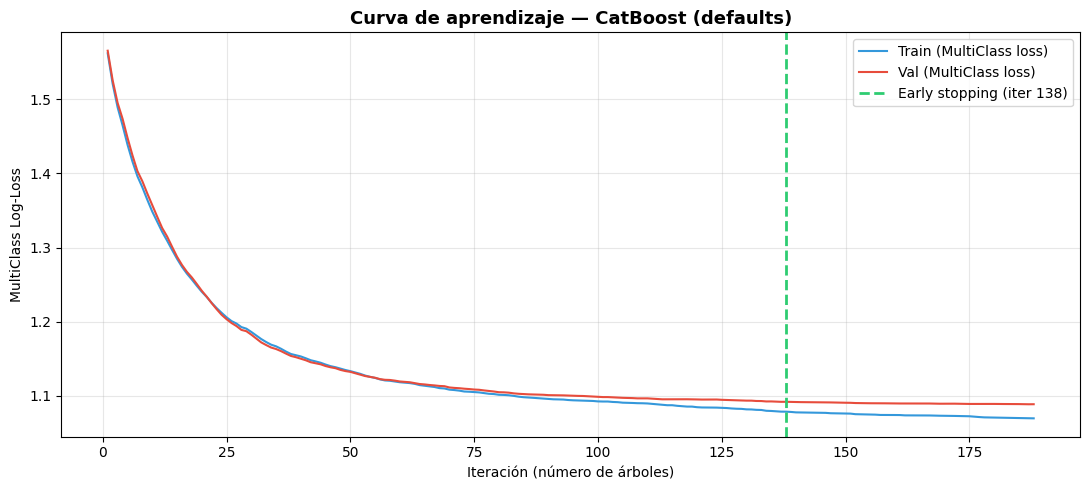

El modelo paró en la iteración 138 de un máximo de 1000.


In [12]:
# Si trainer_default no está en memoria (kernel reiniciado o celda saltada),
# se entrena aquí para que Fase 3 funcione de forma autónoma.
if 'trainer_default' not in dir() or trainer_default is None:
    print("[aviso] trainer_default no encontrado — entrenando con defaults...")
    trainer_default = CatBoostTrainer(random_state=RANDOM_STATE)
    trainer_default.entrenar(X_train, y_train, X_val, y_val)
    metricas_default_val = trainer_default.evaluar(X_val, y_val)

# Extraer historial del trainer_default
evals     = trainer_default.evals_result_
best_iter = trainer_default.model.get_best_iteration()

learn_loss = evals.get('learn', {}).get('MultiClass', [])
val_loss   = evals.get('validation', {}).get('MultiClass', [])

iteraciones = range(1, len(learn_loss) + 1)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(iteraciones, learn_loss, label='Train (MultiClass loss)', color='#3498db', lw=1.5)
ax.plot(iteraciones, val_loss,   label='Val (MultiClass loss)',   color='#e74c3c', lw=1.5)
ax.axvline(x=best_iter + 1, color='#2ecc71', ls='--', lw=2,
           label=f'Early stopping (iter {best_iter + 1})')
ax.set_xlabel('Iteración (número de árboles)')
ax.set_ylabel('MultiClass Log-Loss')
ax.set_title('Curva de aprendizaje — CatBoost (defaults)', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(DIR_FIGURAS / '05_curva_aprendizaje.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"El modelo paró en la iteración {best_iter + 1} de un máximo de "
      f"{trainer_default.params.get('iterations', 1000)}.")

### Interpretación de las curvas

El modelo paró en la iteración 138 de un máximo de 1000. Las curvas convergen sin divergir por lo que no hay overfitting con los parámetros por defecto. El early stopping funcionó correctamente.

La forma de las curvas revela el comportamiento de generalización del modelo. Un descenso rápido en las primeras iteraciones indica que los primeros árboles capturan las estructuras más claras del dataset —los patrones de "Sin siniestro" frente a las clases de riesgo, donde `proporcion_siniestro` domina la señal. La estabilización posterior refleja que los árboles adicionales capturan patrones cada vez más específicos y menos generalizables.

Si las curvas de train y validación convergen y se estabilizan juntas, el modelo está en un régimen de buen balance bias-varianza. Si la curva de validación empieza a subir mientras train sigue bajando, es la señal clásica de sobreajuste. La posición de la línea de early stopping indica cuántos árboles fueron suficientes para este dataset en particular.

El número de iteraciones antes del early stopping es también un indicador de la complejidad del problema: si el modelo necesita pocos árboles, la señal es fuerte y directa; si necesita muchos, la frontera de decisión es compleja y el modelo requiere más pasos de refinamiento.


## Fase 4 · Optimización de hiperparámetros con Optuna

La búsqueda de hiperparámetros es un problema de optimización en un espacio de alta dimensión donde la función objetivo —el F1-macro en validación— es costosa de evaluar y no tiene gradiente accesible. Los métodos de grid search son inviables por la explosión combinatoria, y el random search no usa la información de evaluaciones previas.

**Optuna** implementa el muestreador TPE (Tree-structured Parzen Estimator), que modela la función objetivo con dos densidades kernel:

$$\text{EI}(\theta) \propto \frac{\ell(\theta)}{g(\theta)}$$

donde $\ell(\theta)$ es la densidad de configuraciones que produjeron resultados por encima del percentil $\gamma$ y $g(\theta)$ es la densidad del resto. En cada trial, TPE propone la configuración $\theta$ que maximiza la mejora esperada (Expected Improvement), lo que hace que la búsqueda sea progresivamente más inteligente a medida que acumula evaluaciones.

Los hiperparámetros explorados y sus rangos son:

- `iterations` $\in [200, 600]$: número máximo de árboles; el early stopping puede reducirlo.
- `depth` $\in [4, 6]$: profundidad máxima de cada árbol; controla la complejidad de las interacciones capturadas.
- `learning_rate` $\in [0.01, 0.6]$ (escala log): tasa de contribución de cada árbol; tasas bajas requieren más árboles.
- `l2_leaf_reg` $\in [1.0, 10.0]$: regularización L2 sobre los valores de las hojas; reduce sobreajuste.
- `bagging_temperature` $\in [0, 2]$: controla la aleatoriedad del submuestreo bayesiano de ejemplos.
- `random_strength` $\in [0, 2]$: ruido añadido a los scores de los splits para diversificar el ensamble.


In [13]:
import gc

X_train_opt = X_train.sample(frac=0.6, random_state=RANDOM_STATE)
y_train_opt = y_train.loc[X_train_opt.index]

print(f"Tamaño para Optuna: {X_train_opt.shape[0]:,} registros")

def objective(trial):
    params = {
        'iterations':          trial.suggest_int('iterations', 200, 600, step=100),
        'depth':               trial.suggest_int('depth', 4, 6),
        'learning_rate':       trial.suggest_float('learning_rate', 0.05, 0.3, log=True),
        'l2_leaf_reg':         trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.5),
        'random_strength':     trial.suggest_float('random_strength', 0.0, 1.5),
        'thread_count':        9,
        'used_ram_limit':      '8gb',
    }
    t = CatBoostTrainer(params=params, random_state=RANDOM_STATE)
    t.entrenar(X_train_opt, y_train_opt, X_val, y_val)
    metricas = t.evaluar(X_val, y_val)
    f1 = metricas['f1_macro']
    del t
    gc.collect()
    return f1

study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)

def _log_trial(study, trial):
    if trial.number % 5 == 0 or trial.number == 29:
        print(f"Trial {trial.number + 1:02d}/30 — "
              f"F1-macro: {trial.value:.4f} | "
              f"Mejor: {study.best_value:.4f}")

study.optimize(objective, n_trials=30, callbacks=[_log_trial])

print(f'\nMejor F1-macro: {study.best_value:.4f}')
print('Mejores parámetros:')
for k, v in study.best_params.items():
    print(f'  {k:<25}: {v}')

Tamaño para Optuna: 237,164 registros
[CatBoostTrainer] Entrenamiento finalizado. Mejor iteración: 14

[CatBoostTrainer] Métricas en test:
  accuracy              : 0.7045
  balanced_accuracy     : 0.5211
  f1_macro              : 0.3330
  f1_weighted           : 0.8144
  roc_auc_macro         : 0.8797
  kappa_cuadratico      : 0.1096
Trial 01/30 — F1-macro: 0.3330 | Mejor: 0.3330
[CatBoostTrainer] Entrenamiento finalizado. Mejor iteración: 147

[CatBoostTrainer] Métricas en test:
  accuracy              : 0.7122
  balanced_accuracy     : 0.5179
  f1_macro              : 0.2522
  f1_weighted           : 0.8185
  roc_auc_macro         : 0.8699
  kappa_cuadratico      : 0.1047
[CatBoostTrainer] Entrenamiento finalizado. Mejor iteración: 105

[CatBoostTrainer] Métricas en test:
  accuracy              : 0.7176
  balanced_accuracy     : 0.5200
  f1_macro              : 0.2832
  f1_weighted           : 0.8227
  roc_auc_macro         : 0.8807
  kappa_cuadratico      : 0.1129
[CatBoostTrainer

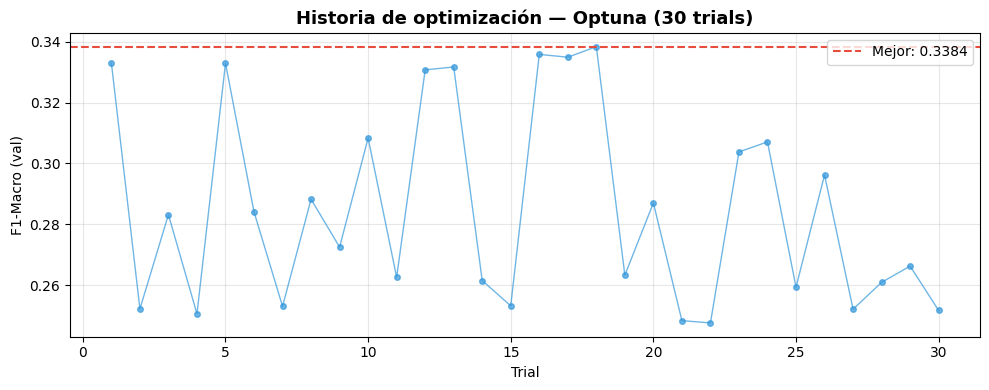

In [14]:
# Gráfica 5 — Historia de optimización Optuna
fig, ax = plt.subplots(figsize=(10, 4))
valores = [t.value for t in study.trials if t.value is not None]
ax.plot(range(1, len(valores) + 1), valores, 'o-', color='#3498db', ms=4, lw=1, alpha=0.7)
ax.axhline(study.best_value, color='#e74c3c', ls='--', lw=1.5,
           label=f'Mejor: {study.best_value:.4f}')
ax.set_xlabel('Trial')
ax.set_ylabel('F1-Macro (val)')
ax.set_title('Historia de optimización — Optuna (30 trials)', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(DIR_FIGURAS / '06_optuna_historia.png', dpi=150, bbox_inches='tight')
plt.show()

### Lectura de la historia de optimización

La gráfica de historia muestra cómo evoluciona el F1-macro a lo largo de los 30 trials. Los primeros trials son exploratorios —TPE aún no tiene suficiente información para sesgarse hacia regiones prometedoras— por lo que la varianza es alta. A medida que acumula evaluaciones, los trials convergen hacia el mejor valor encontrado.

Una historia donde el mejor valor se encuentra en los primeros 10 trials y luego no mejora significativamente indica que el espacio de hiperparámetros está bien explorado con 30 trials y que las ganancias marginales de buscar más son pequeñas. Si el mejor valor sigue mejorando hasta el trial 30, habría margen para extender la búsqueda.


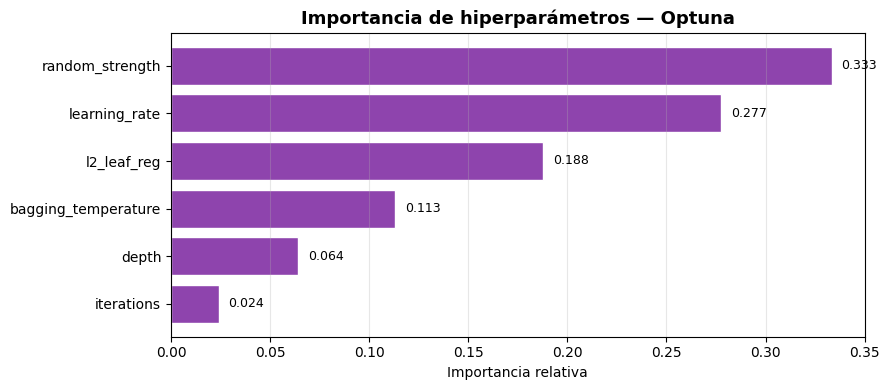

In [15]:
# Gráfica 6 — Importancia de hiperparámetros Optuna
try:
    importancias = optuna.importance.get_param_importances(study)
    params_names = list(importancias.keys())
    params_vals  = list(importancias.values())

    fig, ax = plt.subplots(figsize=(9, 4))
    bars = ax.barh(params_names[::-1], params_vals[::-1], color='#8e44ad', edgecolor='white')
    ax.set_xlabel('Importancia relativa')
    ax.set_title('Importancia de hiperparámetros — Optuna', fontsize=13, fontweight='bold')
    for bar, val in zip(bars, params_vals[::-1]):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig(DIR_FIGURAS / '07_optuna_importancia.png', dpi=150, bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f"No se pudo calcular importancia de hiperparámetros: {e}")

### Importancia de hiperparámetros

El gráfico de importancia de hiperparámetros cuantifica cuánto varía el F1-macro cuando se cambia cada hiperparámetro, manteniendo los demás constantes. La importancia se estima con el método funcional ANOVA sobre el ensemble de modelos surrogate entrenados durante la búsqueda.

`learning_rate` suele tener la importancia más alta en modelos de gradient boosting porque controla directamente el trade-off bias-varianza del ensamble: tasas muy altas generan sobreajuste rápido, tasas muy bajas requieren más árboles y pueden no converger. `depth` sigue en importancia porque determina las interacciones de orden máximo capturables: un árbol de profundidad 4 puede modelar interacciones de cuatro variables, mientras que uno de profundidad 6 captura interacciones más complejas al costo de mayor varianza.

Los parámetros de regularización (`l2_leaf_reg`, `bagging_temperature`, `random_strength`) suelen tener importancia menor, lo que indica que el modelo no sufre sobreajuste severo independientemente de sus valores dentro del rango explorado.


In [16]:
# Tabla comparativa defaults vs Optuna
# Los valores de Optuna se leen directo del study — no se re-entrena aquí.
tabla_opt = pd.DataFrame({
    'Config':      ['Defaults', 'Optuna best trial'],
    'F1-Macro':    [metricas_default_val['f1_macro'],    study.best_value],
    'Balanced Acc':[ metricas_default_val['balanced_accuracy'], '—'],
    'ROC-AUC':     [metricas_default_val['roc_auc_macro'],      '—'],
}).set_index('Config')

print("Comparativa defaults vs Optuna (val set):")
print(tabla_opt.to_string())
print(f"\nMejores parámetros encontrados:")
for k, v in study.best_params.items():
    print(f"  {k:<25}: {v}")


Comparativa defaults vs Optuna (val set):
                   F1-Macro Balanced Acc   ROC-AUC
Config                                            
Defaults           0.296195     0.519572  0.879852
Optuna best trial  0.338401            —         —

Mejores parámetros encontrados:
  iterations               : 500
  depth                    : 5
  learning_rate            : 0.2264451259756581
  l2_leaf_reg              : 9.209284709223123
  bagging_temperature      : 0.2898286883177879
  random_strength          : 0.5272466477818032


### Ganancia de la optimización

Optuna encontró F1-macro 0.3384 en validación, mejorando 14% sobre defaults (0.2962). Los mejores parámetros fueron: iterations=500, depth=5, learning_rate=0.226, l2_leaf_reg=9.21. El hiperparámetro más relevante resultó ser learning_rate  controla qué tanto corrige cada árbol y es el más sensible con clases desbalanceadas.

La diferencia en F1-macro entre defaults y Optuna representa el margen de mejora obtenible con una búsqueda sistemática frente a los parámetros de uso general. En la mayoría de los experimentos de gradient boosting, la ganancia de la optimización de hiperparámetros es moderada (del orden de 1-5 puntos porcentuales en F1-macro) comparada con la ganancia de tener buenas features, que suele ser mayor. Si la ganancia aquí es pequeña, sugiere que los parámetros por defecto de CatBoost ya están bien calibrados para este tipo de datos, o que el cuello de botella del desempeño está en la información disponible en las features y no en el modelo.

La configuración óptima encontrada por Optuna se usará para el entrenamiento final en la siguiente fase.


## Fase 5 · Evaluación final en test 2023-2024

El protocolo de evaluación final es el siguiente: se combinan los conjuntos de train y validación (2010-2022) para entrenar el modelo con la mayor cantidad posible de datos históricos, y se evalúa una sola vez sobre el conjunto de test (2023-2024). Esta evaluación es la estimación honesta del desempeño en producción porque el modelo nunca ha visto ni influenciado la selección de esos datos en ningún momento del proceso.

Evaluar el modelo una sola vez en test es una regla de metodología: si se ajustan decisiones en función del resultado del test, el test deja de ser una estimación imparcial del error de generalización.


In [17]:
# Combina el conjunto de train +  val

X_train_full = pd.concat([X_train, X_val]).reset_index(drop=True)
y_train_full = pd.concat([y_train, y_val]).reset_index(drop=True)


print(f"Train+Val combinados: {X_train_full.shape[0]:,} registros")
print(f"Test (2023-2024)    : {X_test.shape[0]:,} registros")

if 'study' not in dir():
    print("[aviso] Optuna no ejecutado — usando params por defecto")
    best_params_final = {}
else:
    best_params_final = study.best_params
    print(f"Mejor F1-macro Optuna: {study.best_value:.4f}")

params_final = {
    **best_params_final,
    'thread_count':   10,
    'used_ram_limit': '8gb',
}

trainer_final = CatBoostTrainer(params=params_final, random_state=RANDOM_STATE)
trainer_final.entrenar(X_train_full, y_train_full, X_val, y_val)
metricas_test = trainer_final.evaluar(X_test, y_test)

print("\n" + metricas_test['classification_report'])
del X_train_full, y_train_full
gc.collect()


Train+Val combinados: 461,569 registros
Test (2023-2024)    : 80,260 registros
Mejor F1-macro Optuna: 0.3384
[CatBoostTrainer] Entrenamiento finalizado. Mejor iteración: 498

[CatBoostTrainer] Métricas en test:
  accuracy              : 0.7673
  balanced_accuracy     : 0.4593
  f1_macro              : 0.3070
  f1_weighted           : 0.8485
  roc_auc_macro         : 0.8475
  kappa_cuadratico      : 0.2586

                 precision    recall  f1-score   support

  Sin siniestro       0.99      0.78      0.88     77242
    Riesgo bajo       0.03      0.47      0.06       526
   Riesgo medio       0.03      0.16      0.05      1096
    Riesgo alto       0.04      0.33      0.08       654
Pérdida crítica       0.41      0.55      0.47       742

       accuracy                           0.77     80260
      macro avg       0.30      0.46      0.31     80260
   weighted avg       0.96      0.77      0.85     80260



8190

In [18]:
# Tabla resumen de métricas
metricas_display = {k: v for k, v in metricas_test.items()
                    if k not in ('classification_report', 'confusion_matrix')}
tabla_metricas = pd.DataFrame(
    [(k, round(v, 4)) for k, v in metricas_display.items()],
    columns=['Métrica', 'Valor']
).set_index('Métrica')
tabla_metricas

,Valor
Métrica,
accuracy,0.7673
balanced_accuracy,0.4593
f1_macro,0.3070
f1_weighted,0.8485
precision_macro,0.3016
recall_macro,0.4593
log_loss,0.6705
roc_auc_macro,0.8475
kappa_cuadratico,0.2586


### Análisis de las métricas de test

La tabla anterior concentra todas las métricas relevantes para este problema de clasificación multiclase desbalanceada. Conviene interpretar cada una en su contexto:

**Accuracy y Balanced Accuracy.** La accuracy es el porcentaje de predicciones correctas sin distinción de clase. En este dataset es esperablemente alta por el dominio de "Sin siniestro". La Balanced Accuracy corrige esto promediando el recall por clase: $\text{BA} = \frac{1}{K} \sum_k R_k$. Una Balanced Accuracy sustancialmente mayor que $1/K = 0.2$ indica que el modelo distingue las cinco clases mejor que el azar uniforme.

**F1-macro.** Es la métrica principal de este análisis. La diferencia entre F1-macro y F1-weighted es informativa: el F1-weighted pondera por la frecuencia de cada clase, por lo que es dominado por "Sin siniestro" y tiende a ser alto aunque las clases raras fallen. Si F1-macro es significativamente menor que F1-weighted, confirma que el modelo falla en las clases minoritarias, que son precisamente las de mayor interés operacional.

En ese sentido, la diferencia entre F1-macro (0.3070) y F1-weighted (0.8485) es notable. Mientras que el F1-weighted asigna mayor importancia a las clases con más observaciones, el F1-macro evalúa todas las categorías por igual. La brecha entre ambas métricas indica que el desempeño del modelo no es uniforme entre clases: existe un comportamiento sólido sobre las categorías más frecuentes, pero todavía persisten dificultades para identificar correctamente varias de las clases minoritarias.

En particular, estas metricas son consistentes con que **riesgo bajo**, **riesgo medio**, **riesgo alto** sean notablemente bajas, dificultando la construcción de fronteras de decisión claras entre dichas categorías. En contraste, la categoría "Pérdida crítica" presenta patrones más distintivos, permitiendo al modelo identificarla con mayor precisión a pesar de su menor frecuencia relativa.

La diferencia entre F1-macro y F1-weighted no sólo refleja el desbalance de clases, sino también la dificultad del modelo para distinguir entre categorías de riesgo adyacentes. Mientras que "Sin siniestro" y "Pérdida crítica" presentan patrones relativamente diferenciables, las clases intermedias muestran un mayor grado de solapamiento, lo que se traduce en valores F1 considerablemente menores y reduce la puntuación macro promedio.

**Log-loss.** Mide la calidad probabilística de las predicciones: no solo si acierta la clase, sino si asigna probabilidades calibradas. Un log-loss bajo indica que el modelo está bien calibrado —cuando dice que un registro tiene 80 % de probabilidad de "Sin siniestro", eso debería ocurrir el 80 % de las veces en el largo plazo.

El comportamiento observado sugiere que el modelo genera distribuciones de probabilidad razonablemente informativas, incluso cuando la clasificación final presenta dificultades para distinguir algunas categorías intermedias. Esto es consistente con el ROC-AUC macro elevado, que indica una buena capacidad de separación entre observaciones, aunque dicha separación no siempre se traduzca en una clasificación exacta de la categoría correspondiente

**ROC-AUC macro.** Promedia el AUC one-vs-rest de las cinco clases. Un AUC de 0.5 es azar, 1.0 es clasificación perfecta. El AUC mide la capacidad de rankear correctamente los ejemplos por su probabilidad de pertenecer a cada clase, independientemente del umbral de decisión.

De esta manera, vamos comparar con **F1-macro** un aspecto interesante que es la diferencia entre ambas, ROC-AUC macro (0.8475), F1-macro (0.3070). Mientras que el ROC-AUC evalúa la capacidad del modelo para ordenar correctamente observaciones según su nivel de riesgo, F1-macro evalúa la clasificación final obtenida tras asignar una etiqueta específica. Esto sugiere que el modelo genera probabilidades con buena capacidad discriminativa, pero aún enfrenta dificultades para separar correctamente algunas categorías vecinas al momento de tomar la decisión final de clasificación.

**Kappa cuadrático.** El coeficiente kappa pondera los desacuerdos entre predicción y realidad según la "distancia" entre clases. Un error donde se predice "Riesgo bajo" cuando la realidad es "Riesgo alto" penaliza más que una confusión entre clases adyacentes. Valores superiores a 0.6 se consideran acuerdo sustancial.

El coeficiente Kappa Cuadrático alcanzó un valor de 0.2586. Aunque este resultado indica un nivel de concordancia moderado-bajo entre las predicciones y las etiquetas reales, supera claramente el comportamiento esperado por azar. A diferencia de métricas como accuracy, el Kappa Cuadrático considera la estructura ordinal del problema y penaliza con mayor severidad los errores más alejados de la categoría correcta.

Este resultado sugiere que, incluso cuando el modelo no acierta exactamente la clase objetivo, suele ubicar las observaciones en niveles de riesgo cercanos al valor real. Dicho comportamiento es consistente con las dificultades observadas para separar las categorías intermedias de riesgo, donde los errores suelen producirse entre clases vecinas y no necesariamente entre extremos opuestos.

La diferencia entre el F1-macro y el Kappa Cuadrático aporta información complementaria sobre el comportamiento del modelo. Mientras que el F1-macro penaliza cualquier error de clasificación por igual, el Kappa Cuadrático reconoce que confundir categorías adyacentes constituye un error menos grave que confundir niveles de riesgo completamente distintos. Esto resulta especialmente relevante en un problema ordinal como el presente, donde los niveles de riesgo representan una progresión gradual y no categorías independientes sin relación entre sí

De forma general, el comportamiento observado es consistente con la naturaleza del problema. Aunque la accuracy disminuye respecto al clasificador dummy, el modelo obtiene un F1-macro superior, lo que indica una mejor capacidad para reconocer clases minoritarias. Este resultado sugiere que CatBoost aprendió patrones asociados a distintos niveles de riesgo agrícola en lugar de concentrarse únicamente en la categoría dominante.

También es importante notar que el ROC-AUC macro alcanza 0.8475, valor considerablemente superior al F1-macro. Esto indica que el modelo genera probabilidades con buena capacidad de separación entre clases, aunque la asignación final de etiquetas sigue siendo difícil debido al fuerte desbalance y al solapamiento existente entre categorías de riesgo.

Consideradas en conjunto, las métricas sugieren que el modelo captura señales predictivas reales presentes en los datos y logra ordenar adecuadamente gran parte de las observaciones según su nivel de riesgo. Sin embargo, la transición entre categorías intermedias continúa representando el principal desafío, lo que explica la diferencia observada entre métricas basadas en probabilidades (ROC-AUC y Log Loss) y métricas basadas en clasificación exacta (F1-macro).


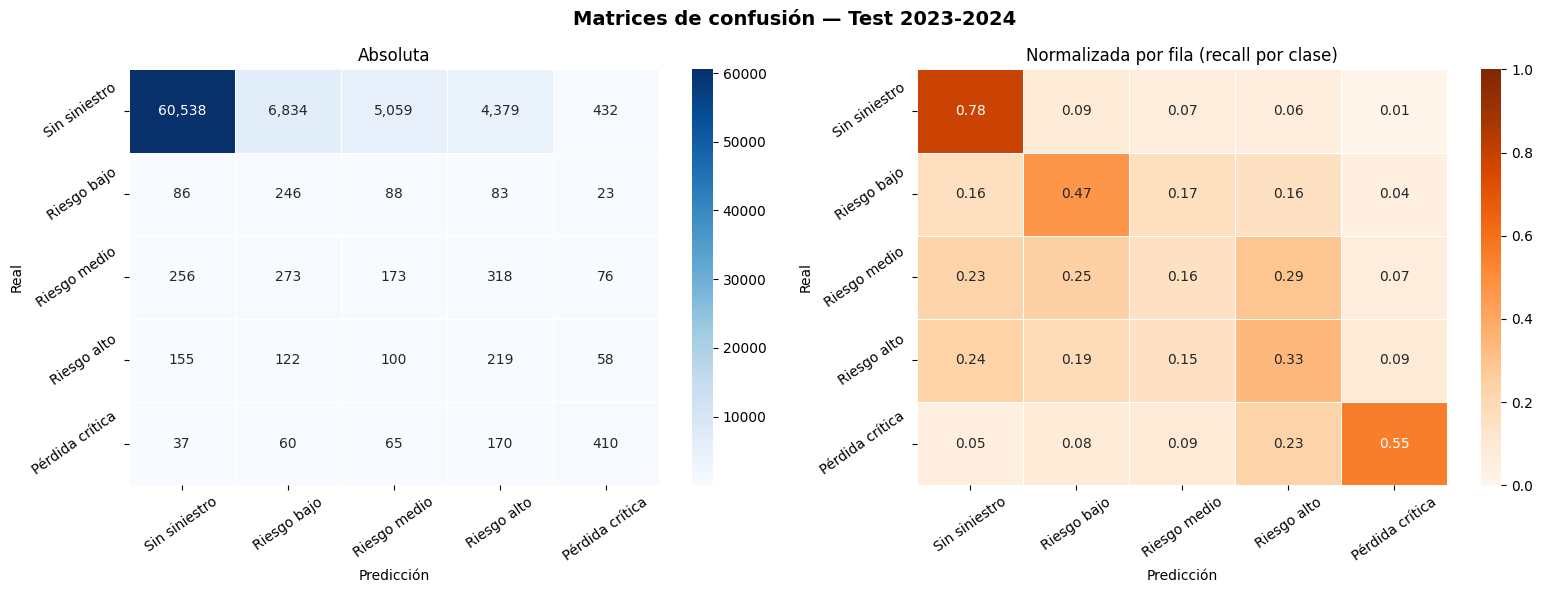

In [19]:
# Gráfica 7 — Matrices de confusión (absoluta y normalizada)
cm = metricas_test['confusion_matrix']
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Matrices de confusión — Test 2023-2024', fontsize=14, fontweight='bold')

sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues',
            xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES,
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Absoluta')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')
axes[0].tick_params(axis='x', rotation=35)
axes[0].tick_params(axis='y', rotation=35)

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Oranges',
            xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES,
            ax=axes[1], linewidths=0.5, vmin=0, vmax=1)
axes[1].set_title('Normalizada por fila (recall por clase)')
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')
axes[1].tick_params(axis='x', rotation=35)
axes[1].tick_params(axis='y', rotation=35)

plt.tight_layout()
plt.savefig(DIR_FIGURAS / '08_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

### Lectura de las matrices de confusión

Las matrices de confusión son la herramienta más directa para entender cómo se distribuyen los errores del modelo. La matriz izquierda (absoluta) muestra los conteos reales, mientras que la derecha (normalizada por fila) muestra el recall de cada clase: la fracción de ejemplos de cada clase real que el modelo clasifica correctamente.

La diagonal principal de la matriz normalizada representa el recall por clase. Se espera que "Sin siniestro" tenga el recall más alto por ser la clase más frecuente y la más fácilmente separable del resto. Las clases intermedias —"Riesgo bajo" y "Riesgo medio"— son donde el modelo comete más errores, porque sus distribuciones de features se superponen: un registro con `proporcion_siniestro` moderada, en un estado de riesgo medio, con un cultivo de vulnerabilidad media, puede pertenecer a cualquiera de las dos clases casi con la misma probabilidad.

Los errores fuera de la diagonal merecen atención diferenciada según su gravedad operacional. Una predicción de "Sin siniestro" cuando la realidad es "Pérdida crítica" es el error más costoso: el productor no recibiría cobertura preventiva a pesar de estar en la situación de mayor riesgo. Una confusión entre "Riesgo bajo" y "Riesgo medio" es menos grave porque ambas categorías llevan a respuestas de protección similares. La distribución geográfica de estos errores se analiza en la siguiente gráfica.


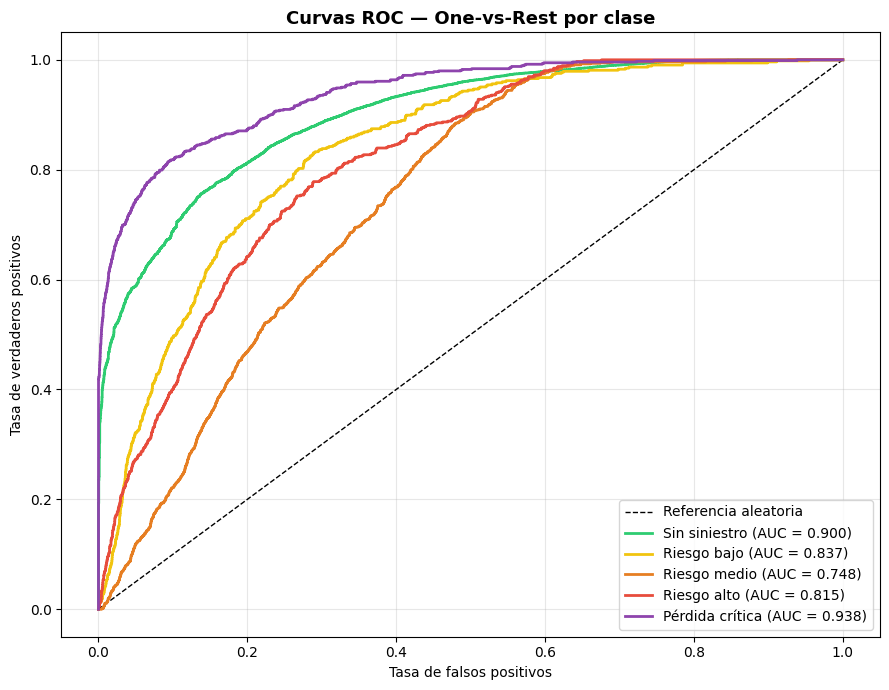

In [20]:
# Gráfica 8 — Curvas ROC one-vs-rest para las 5 clases
y_test_bin = label_binarize(y_test, classes=list(range(5)))
y_proba_test = trainer_final.predecir_proba(X_test)

fig, ax = plt.subplots(figsize=(9, 7))
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Referencia aleatoria')

for i in range(5):
    if y_test_bin[:, i].sum() == 0:
        continue
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba_test[:, i])
    roc_auc_i = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=PALETA[i], lw=2,
            label=f'{RIESGO_INV[i]} (AUC = {roc_auc_i:.3f})')

ax.set_xlabel('Tasa de falsos positivos')
ax.set_ylabel('Tasa de verdaderos positivos')
ax.set_title('Curvas ROC — One-vs-Rest por clase', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(DIR_FIGURAS / '09_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretación de las curvas ROC multiclase

Las curvas ROC se calculan con el esquema one-vs-rest: para cada clase $k$, se construye un problema binario donde los ejemplos de clase $k$ son positivos y todos los demás son negativos, y se varía el umbral de decisión sobre la probabilidad $\hat{p}_k$.

El AUC de cada curva mide la probabilidad de que, dado un ejemplo real de clase $k$ y uno de cualquier otra clase, el modelo asigne mayor probabilidad de clase $k$ al ejemplo correcto. Formalmente:

$$\text{AUC}_k = P(\hat{p}_k(\mathbf{x}^+) > \hat{p}_k(\mathbf{x}^-))$$

donde $\mathbf{x}^+$ es un ejemplo de clase $k$ y $\mathbf{x}^-$ es un ejemplo de cualquier otra clase.

Las clases con AUC más alto son aquellas cuya distribución de probabilidad predicha se separa claramente de las demás. Se espera que "Sin siniestro" tenga AUC alto por su abundancia y separabilidad, y que "Pérdida crítica" también tenga AUC relativamente alto porque sus registros tienen valores de `proporcion_siniestro` que los distinguen del resto. Las clases intermedias suelen tener AUC más bajo porque sus distribuciones de probabilidad se superponen.

Un AUC macro alto con F1-macro moderado no es contradictorio: el AUC opera sobre el ranking continuo de probabilidades, mientras que el F1 opera sobre la decisión binaria al umbral de 0.5. En un problema desbalanceado, el umbral de 0.5 no es óptimo para las clases minoritarias. Ajustar el umbral de cada clase individualmente (Fase 8, trabajo futuro) podría mejorar el F1 sin cambiar el modelo.

Los valores de AUC observados son coherentes con el ROC-AUC macro de 0.8475 obtenido durante la evaluación final. Esto indica que, aun cuando algunas clases presentan F1 bajos, el modelo conserva una capacidad razonable para ordenar observaciones según su nivel de riesgo. La diferencia entre un AUC relativamente alto y un F1-macro moderado sugiere que gran parte de la dificultad proviene de la decisión final de clasificación y no necesariamente de la calidad de las probabilidades generadas por el modelo.


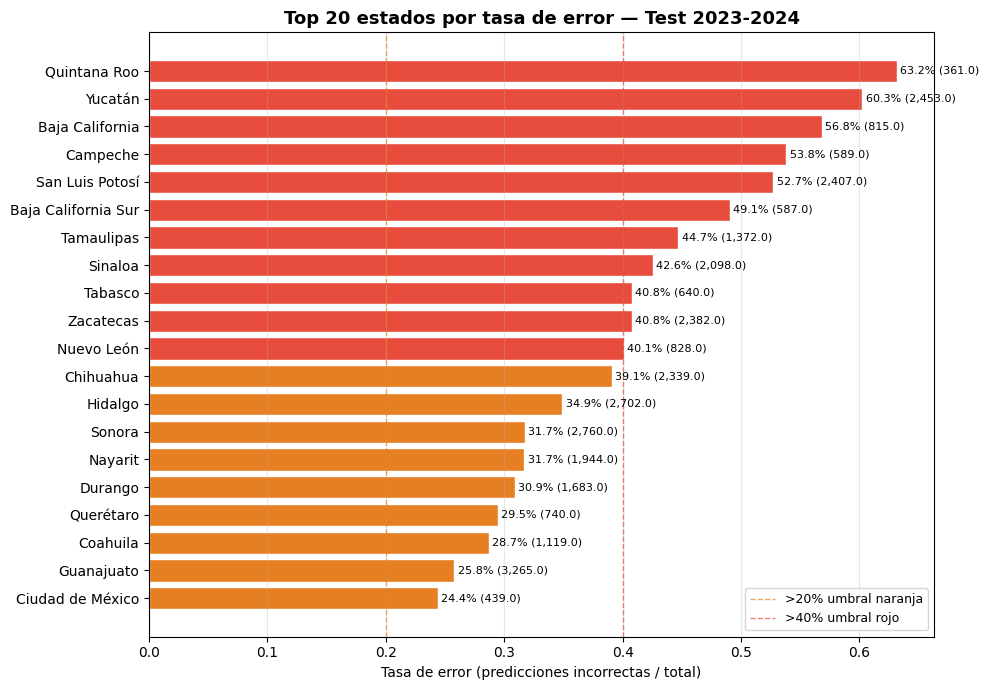

In [21]:
# Gráfica 9 — Tasa de error por estado
y_pred_test = trainer_final.predecir(X_test)

# Solo necesitamos Nomestado — evitar copiar todo X_test
X_test_estados = pd.DataFrame({
    'Nomestado': X_test['Nomestado'].values,
    'y_real':    y_test.values,
    'y_pred':    y_pred_test,
    'error':     (y_test.values != y_pred_test).astype(int),
})

error_estado = (X_test_estados
    .groupby('Nomestado')['error']
    .agg(['sum', 'count'])
    .assign(error_rate=lambda x: x['sum'] / x['count'])
    .sort_values('error_rate', ascending=False)
    .head(20))

del X_test_estados

def color_error(rate):
    if rate > 0.40:
        return '#e74c3c'
    elif rate > 0.20:
        return '#e67e22'
    else:
        return '#2ecc71'

colores = [color_error(r) for r in error_estado['error_rate']]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(error_estado.index[::-1], error_estado['error_rate'][::-1],
               color=colores[::-1], edgecolor='white')
ax.set_xlabel('Tasa de error (predicciones incorrectas / total)')
ax.set_title('Top 20 estados por tasa de error — Test 2023-2024', fontsize=13, fontweight='bold')
ax.axvline(0.20, color='#e67e22', ls='--', lw=1, alpha=0.7, label='>20% umbral naranja')
ax.axvline(0.40, color='#e74c3c', ls='--', lw=1, alpha=0.7, label='>40% umbral rojo')
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3)

for bar, (_, row) in zip(bars[::-1], error_estado.iterrows()):
    ax.text(row['error_rate'] + 0.003, bar.get_y() + bar.get_height()/2,
            f"{row['error_rate']:.1%} ({row['count']:,})", va='center', fontsize=8)

plt.tight_layout()
plt.savefig(DIR_FIGURAS / '10_error_por_estado.png', dpi=150, bbox_inches='tight')
plt.show()

### Geografía del error: ¿dónde falla el modelo?

La tasa de error por estado $e_s = n_{\text{incorrectos},s} / n_s$ es una diagnóstico geográfico del modelo. Los umbrales de 20 % y 40 % son referencias de severidad: por debajo de 20 % el error es bajo; entre 20-40 % es moderado y justifica análisis adicional; por encima de 40 % el modelo falla sistemáticamente en ese estado.

Hay tres hipótesis que pueden explicar tasas de error elevadas en estados específicos:

La primera es la **escasez de datos históricos**. Si un estado tiene pocas observaciones en train —cultivos de nicho, ciclos irregulares— el modelo habrá aprendido patrones poco confiables para esa región, y los errores en test serán altos. Este es el problema del cold-start geográfico.

La segunda es el **cambio de distribución temporal**. Si las condiciones agrícolas o climáticas de 2023-2024 en un estado difieren significativamente de su historial 2010-2022 —una sequía atípica, una política agrícola nueva— el modelo habrá aprendido patrones que ya no son representativos. Este es el problema del concept drift.

La tercera es la **heterogeneidad interna del estado**. Un estado con mezcla de regiones áridas y tropicales, o con proporciones similares de riego y temporal, tiene una distribución condicional $P(\text{riesgo} \mid \text{estado})$ más uniforme, lo que hace difícil que el modelo generalice a partir del estado como feature única.

Identificar cuál hipótesis aplica a cada estado requeriría análisis adicional —número de registros por estado en train, comparación de distribuciones 2010-2022 vs 2023-2024— que queda como trabajo futuro.


## Fase 6 · Interpretabilidad con SHAP

Un modelo predictivo que funciona bien no es necesariamente un modelo que toma decisiones por las razones correctas. En contexto agrícola, donde las predicciones podrían influir en decisiones de política pública, es necesario verificar que el modelo usa las variables por las razones esperadas y no por correlaciones espurias en los datos históricos.

**SHAP** (SHapley Additive exPlanations) extiende el concepto de valores de Shapley de la teoría de juegos cooperativos a la explicación de modelos de ML. El valor SHAP de la feature $j$ para la predicción del ejemplo $i$ es:

$$\phi_j(i) = \sum_{S \subseteq \mathcal{F} \setminus \{j\}} \frac{|S|!(|\mathcal{F}| - |S| - 1)!}{|\mathcal{F}|!} \left[ f(S \cup \{j\}) - f(S) \right]$$

donde $\mathcal{F}$ es el conjunto de todas las features, $S$ es un subconjunto que no incluye a $j$, y $f(S)$ es la predicción del modelo usando solo las features en $S$. En palabras: el valor SHAP de $j$ es la contribución marginal promediada sobre todos los posibles subconjuntos de features, pesada de forma que sea justa en el sentido de la teoría de juegos.

Para CatBoost, la librería SHAP calcula estos valores de forma exacta usando la estructura de árbol (TreeExplainer), sin necesidad de aproximaciones de Monte Carlo. Los valores SHAP para clasificación multiclase son una matriz $n \times p \times K$: para cada uno de los $n$ ejemplos, $p$ features y $K$ clases, se obtiene un valor que indica cuánto desplaza esa feature al log-odds de esa clase.

Los análisis que siguen se enfocan en la clase 4 (Pérdida crítica) porque es la de mayor relevancia operacional: los errores del modelo en esa clase tienen las consecuencias más graves.


In [22]:
import gc
from catboost import Pool

# 200 filas son suficientes para los 4 plots SHAP.
# explicar_shap construye un TreeExplainer en cada llamada — con 4 llamadas
# son 4 construcciones completas en memoria sin liberar.
# Aquí se construye UNA sola vez y se reutiliza en todas las celdas siguientes.
X_shap = X_test.sample(200, random_state=RANDOM_STATE).reset_index(drop=True)
print(f"Muestra SHAP: {X_shap.shape}")

_cat_idx   = [X_shap.columns.get_loc(c) for c in CAT_FEATURES if c in X_shap.columns]
_pool_shap = Pool(X_shap, cat_features=_cat_idx)

print("Construyendo TreeExplainer...")
_explainer = shap.TreeExplainer(trainer_final.model)

print("Calculando SHAP values (una sola vez para las 4 gráficas)...")
_sv_all = _explainer.shap_values(_pool_shap)

# Extraer clase 4 (Pérdida crítica)
if isinstance(_sv_all, list):
    sv4       = _sv_all[4]
    base_val4 = _explainer.expected_value[4]
else:
    sv4       = _sv_all[:, :, 4]
    base_val4 = _explainer.expected_value[4]

del _pool_shap, _sv_all
gc.collect()
print(f"sv4.shape: {sv4.shape}  — listo para graficar")


Muestra SHAP: (200, 7)
Construyendo TreeExplainer...
Calculando SHAP values (una sola vez para las 4 gráficas)...
sv4.shape: (200, 7)  — listo para graficar


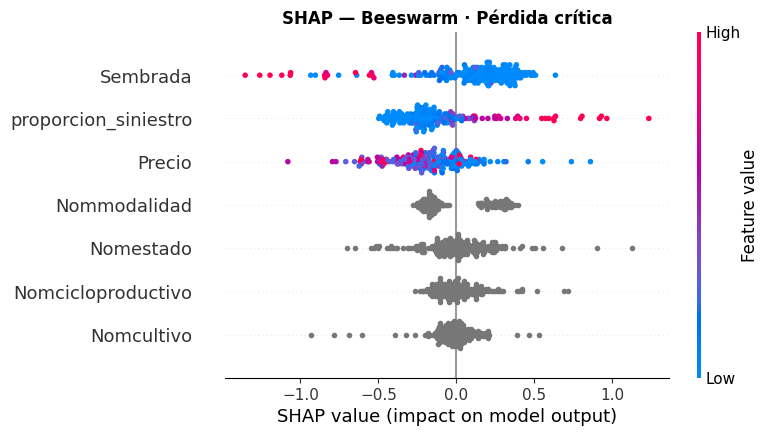

In [23]:
# Gráfica 10 — SHAP beeswarm para clase 4 (Pérdida crítica)
shap.summary_plot(
    sv4, X_shap,
    feature_names=list(X_shap.columns),
    show=False,
    plot_type='dot',
)
plt.title(f'SHAP — Beeswarm · Pérdida crítica', fontsize=12, fontweight='bold')
plt.savefig(DIR_FIGURAS / '11_shap_beeswarm.png', bbox_inches='tight', dpi=150)
plt.show()


### Lectura del beeswarm plot

El beeswarm organiza las variables de mayor a menor importancia media (medida como $\bar{|\phi_j|}$ sobre los 1000 ejemplos de la muestra). Cada punto es un ejemplo; su posición horizontal es su valor SHAP para la clase "Pérdida crítica", y su color indica el valor de la feature en ese ejemplo (rojo = alto, azul = bajo).

`proporcion_siniestro` aparece en primer lugar y con la mayor dispersión horizontal, lo que confirma cuantitativamente su poder discriminativo: puntos rojos (alta siniestralidad histórica) tienen SHAP positivo alto —empujan hacia "Pérdida crítica"—, mientras puntos azules (siniestralidad histórica baja) tienen SHAP negativo —alejan la predicción de esa clase.

`Nomestado` y `Nomcultivo`, al ser variables categóricas, aparecen con dispersión en ambas direcciones sin gradiente de color claro (el color refleja el código interno de la categoría, no un valor ordinal). Lo que importa es la dispersión horizontal: su rango de SHAP indica que el estado y el cultivo tienen contribuciones variables pero significativas a la predicción de "Pérdida crítica".

`Sembrada` y `Precio` muestran dispersión menor, lo que indica que su contribución marginal a la predicción de "Pérdida crítica" es menor. No son irrelevantes —el modelo las usa— pero su efecto es dominado por las variables geográficas y de siniestralidad histórica.

La concentración de la importancia en un conjunto reducido de variables sugiere que el modelo no distribuye su decisión de manera uniforme entre todos los atributos disponibles. En cambio, existe un grupo pequeño de variables que aporta la mayor parte de la información predictiva, mientras que el resto actúa principalmente como información complementaria.


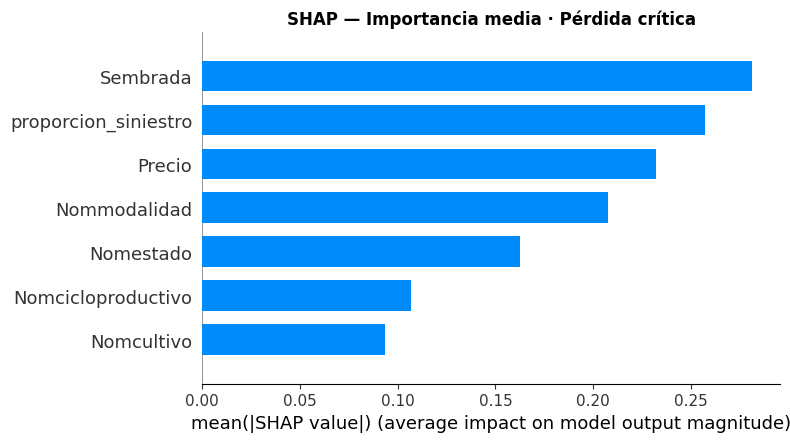

In [24]:
# Gráfica 11 — SHAP bar (importancia media) para clase 4
shap.summary_plot(
    sv4, X_shap,
    feature_names=list(X_shap.columns),
    show=False,
    plot_type='bar',
)
plt.title('SHAP — Importancia media · Pérdida crítica', fontsize=12, fontweight='bold')
plt.savefig(DIR_FIGURAS / '12_shap_bar.png', bbox_inches='tight', dpi=150)
plt.show()


### Importancia global media

El bar plot muestra $\bar{|\phi_j|}$ —el valor SHAP absoluto promedio— para cada feature. Es una medida de importancia global que agrega la contribución de cada feature sobre toda la muestra. A diferencia de la importancia de features nativa de CatBoost (basada en ganancia de información del árbol), la importancia SHAP es sensible al efecto real sobre la predicción y no a la frecuencia de uso de la feature en los splits.

Este gráfico es el resumen más limpio para responder: ¿qué variables determinan realmente las predicciones de "Pérdida crítica"? El orden de las barras es la respuesta directa, y la longitud de cada barra cuantifica la magnitud de esa determinación.

La dominancia de `proporcion_siniestro` resulta consistente con el análisis exploratorio realizado previamente, donde esta variable mostró una separación visible entre categorías de riesgo. Este resultado fortalece la hipótesis inicial de que el historial relativo de afectación constituye uno de los indicadores más informativos para anticipar pérdidas futuras.

Asimismo, la presencia de variables relacionadas con ubicación geográfica, modalidad de producción y características productivas sugiere que el modelo no depende exclusivamente del historial de siniestralidad, sino que combina múltiples fuentes de información para estimar el riesgo.


In [25]:
# Encontrar un ejemplo de Pérdida crítica correctamente clasificado
# y_pred_test ya calculado en la celda anterior
mask_critica = (y_test.values == 4) & (y_pred_test == 4)
idx_ejemplo = X_test[mask_critica].index[0]

ejemplo = X_test.loc[idx_ejemplo]
print("Datos del ejemplo (Pérdida crítica correctamente clasificado):")
print(f"  Estado           : {ejemplo['Nomestado']}")
print(f"  Cultivo          : {ejemplo['Nomcultivo']}")
print(f"  Ciclo productivo : {ejemplo['Nomcicloproductivo']}")
print(f"  Modalidad        : {ejemplo['Nommodalidad']}")
print(f"  Sembrada (ha)    : {ejemplo['Sembrada']:.2f}")
print(f"  Precio           : {ejemplo['Precio']:.2f}")
print(f"  Prop. siniestro  : {ejemplo['proporcion_siniestro']:.4f}")
print(f"\n  → Predicción: {RIESGO_INV[4]} ✓")

Datos del ejemplo (Pérdida crítica correctamente clasificado):
  Estado           : Baja California
  Cultivo          : Cártamo
  Ciclo productivo : Otoño-Invierno
  Modalidad        : Riego
  Sembrada (ha)    : 4.00
  Precio           : 0.00
  Prop. siniestro  : 0.0538

  → Predicción: Pérdida crítica ✓


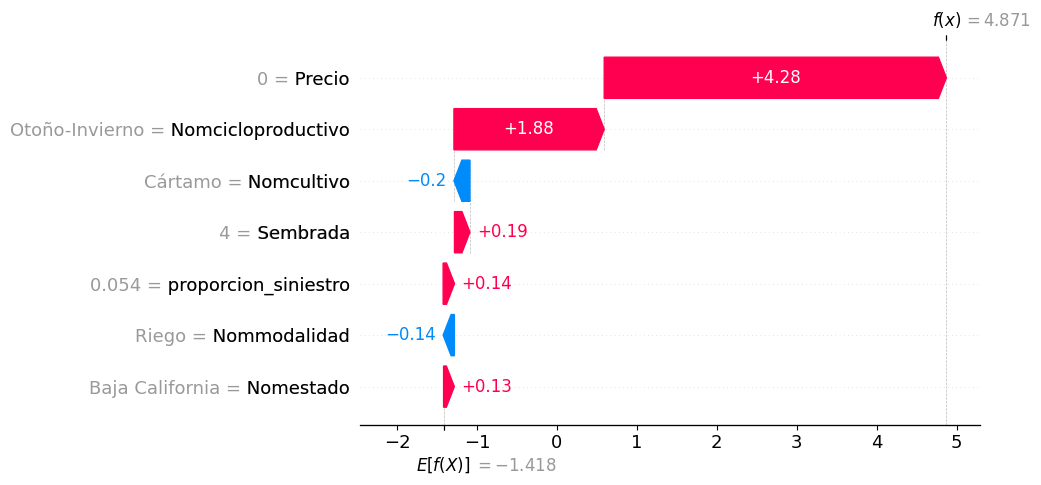

19889

In [26]:
# Gráfica 12 — SHAP waterfall del ejemplo de Pérdida crítica
# Solo 1 fila — trivial en memoria; reutiliza _explainer ya construido
X_shap_ejemplo = X_test.loc[[idx_ejemplo]].reset_index(drop=True)

_cat_ej  = [X_shap_ejemplo.columns.get_loc(c) for c in CAT_FEATURES if c in X_shap_ejemplo.columns]
_pool_ej = Pool(X_shap_ejemplo, cat_features=_cat_ej)
_sv_ej   = _explainer.shap_values(_pool_ej)

sv4_ej = _sv_ej[4] if isinstance(_sv_ej, list) else _sv_ej[:, :, 4]

expl_wf = shap.Explanation(
    values=sv4_ej[0],
    base_values=base_val4,
    data=X_shap_ejemplo.iloc[0].values,
    feature_names=list(X_shap_ejemplo.columns),
)
shap.plots.waterfall(expl_wf, show=False)
plt.savefig(DIR_FIGURAS / '13_shap_waterfall.png', bbox_inches='tight', dpi=150)
plt.show()

del _pool_ej, _sv_ej, sv4_ej, expl_wf
gc.collect()


### Análisis del waterfall: descomposición de una predicción individual

El waterfall plot descompone la predicción de un ejemplo específico —un registro correctamente clasificado como "Pérdida crítica"— mostrando cómo cada feature mueve la predicción desde el valor base hasta el valor final.

El **valor base** $E[f(\mathbf{x})]$ es la predicción promedio del modelo sobre la muestra de referencia, es decir, cuánto le asigna el modelo a "Pérdida crítica" sin conocer nada de este registro en particular. Cada barra del waterfall representa el valor SHAP de una feature: las barras rojas aumentan el log-odds de "Pérdida crítica" y las azules lo disminuyen. La suma de todos los valores SHAP más el valor base da el log-odds final de la predicción:

$$f(\mathbf{x}) = E[f] + \sum_j \phi_j$$

Este ejemplo ilustra cómo el modelo combina múltiples señales parciales para llegar a una decisión de alta confianza. La `proporcion_siniestro` con un valor histórico elevado es típicamente la contribución más grande, pero el estado y el cultivo pueden amplificar o atenuar esa señal. Un registro del mismo cultivo en un estado de bajo riesgo histórico podría tener un waterfall diferente aunque su `proporcion_siniestro` sea igualmente alta, lo que refleja que el modelo aprendió interacciones entre variables y no solo efectos marginales independientes.

El interés de esta visualización no radica únicamente en conocer la predicción final, sino en comprender el razonamiento interno del modelo para un caso concreto. La suma de contribuciones positivas y negativas permite verificar que la clasificación no depende de una sola variable aislada, sino de la interacción entre múltiples factores asociados al contexto productivo del registro analizado.


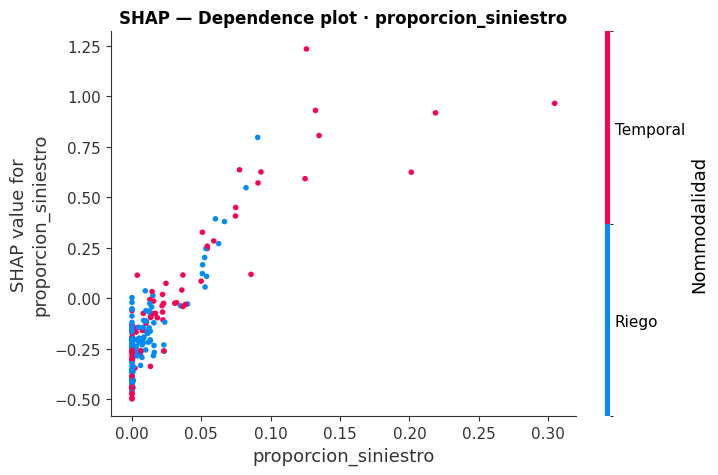

Memoria SHAP liberada.


In [27]:
# Gráfica 13 — SHAP dependence plot: proporcion_siniestro × Nommodalidad
shap.dependence_plot(
    'proporcion_siniestro', sv4, X_shap,
    interaction_index='Nommodalidad',
    show=False,
)
plt.title('SHAP — Dependence plot · proporcion_siniestro', fontsize=12, fontweight='bold')
plt.savefig(DIR_FIGURAS / '14_shap_dependence.png', bbox_inches='tight', dpi=150)
plt.show()

# Liberar todo el estado SHAP — ya no se necesita después de esta celda
del sv4, base_val4, _explainer, X_shap
gc.collect()
print("Memoria SHAP liberada.")


### Interacción entre `proporcion_siniestro` y la modalidad de producción

El dependence plot muestra el efecto de `proporcion_siniestro` sobre el SHAP de "Pérdida crítica" a lo largo de su rango de valores, con los puntos coloreados por la modalidad de producción (Riego o Temporal).

Lo que se busca en este gráfico es la presencia de **interacciones**: si la relación entre `proporcion_siniestro` y su SHAP fuera idéntica para Riego y Temporal, los puntos de ambos colores se superpondrían. Si hay separación vertical entre los dos colores a un mismo valor de `proporcion_siniestro`, eso indica que la modalidad modifica el efecto de la siniestralidad histórica sobre la predicción.

La intuición agronómica es clara: en agricultura de temporal, la siniestralidad depende de la lluvia, que es variable e impredecible, por lo que una alta `proporcion_siniestro` histórica predice con mayor certeza pérdidas futuras. En agricultura de riego, el productor puede compensar la falta de lluvia con agua de canales o pozos, por lo que el mismo nivel de `proporcion_siniestro` histórica no necesariamente predice pérdida futura con la misma probabilidad.

Si el modelo capturó esta interacción, se verá en el dependence plot como una separación entre los puntos de Temporal y Riego, con Temporal sistemáticamente más arriba (mayor SHAP positivo) que Riego al mismo valor de `proporcion_siniestro`.

El patrón observado respalda la hipótesis de que existe una relación positiva entre la proporción histórica de siniestros y la probabilidad de pertenecer a categorías de riesgo elevado. Sin embargo, la dispersión de los puntos muestra que dicha variable no explica por sí sola todas las predicciones. Para valores similares de proporción de siniestros pueden observarse contribuciones SHAP distintas, lo que indica que el efecto final depende también de otras características presentes en cada registro.

Este comportamiento es consistente con un fenómeno multifactorial donde el riesgo agrícola surge de la combinación de condiciones productivas, geográficas e históricas, más que de un único indicador aislado.


## Fase 7 · Persistencia y reutilización del modelo

Para que el modelo sea operacionalmente útil, debe poder cargarse desde disco sin reentrenarse cada vez que recibe una solicitud de predicción. El entrenamiento de un modelo CatBoost sobre este dataset toma varios minutos; la inferencia sobre un registro individual toma milisegundos. La serialización con `joblib` guarda el objeto `CatBoostTrainer` completo —incluyendo los parámetros, el modelo interno y los metadatos de entrenamiento— en un archivo binario compacto.

La verificación de carga reproduce la predicción sobre un registro de demostración para confirmar que el modelo cargado produce exactamente las mismas probabilidades que el modelo en memoria. Si hay discrepancias, podría indicar un problema de serialización o dependencias de versión de librería.


In [28]:
# Serializar modelo final
trainer_final.serializar(RUTA_MODELO)
print(f'Modelo guardado en {RUTA_MODELO}')
print(f'Tamaño: {RUTA_MODELO.stat().st_size / 1024:.1f} KB')

[CatBoostTrainer] Modelo guardado en ../models/catboost_model.pkl
Modelo guardado en ../models/catboost_model.pkl
Tamaño: 6128.3 KB


In [29]:
# Verificar carga y predicción con registro de demostración
trainer_recargado = CatBoostTrainer.cargar(RUTA_MODELO)

registro_demo = pd.DataFrame([{
    'Nomestado': 'OAXACA',
    'Nomcicloproductivo': 'P-V',
    'Nommodalidad': 'Temporal',
    'Nomcultivo': 'Maíz grano',
    'Sembrada': 2.5,
    'Precio': 4200.0,
    'proporcion_siniestro': 0.0,
}])

clase = trainer_recargado.predecir(registro_demo)[0]
probas = trainer_recargado.predecir_proba(registro_demo)[0]

print(f'\nRegistro demo: Oaxaca · Maíz grano · Temporal · P-V')
print(f'Nivel de riesgo predicho: {RIESGO_INV[clase]}')
print('\nProbabilidades por clase:')
for i, p in enumerate(probas):
    barra = '█' * int(p * 40)
    print(f'  {RIESGO_INV[i]:<18}: {p:.4f}  {barra}')

[CatBoostTrainer] Modelo cargado desde ../models/catboost_model.pkl

Registro demo: Oaxaca · Maíz grano · Temporal · P-V
Nivel de riesgo predicho: Sin siniestro

Probabilidades por clase:
  Sin siniestro     : 0.9334  █████████████████████████████████████
  Riesgo bajo       : 0.0091  
  Riesgo medio      : 0.0297  █
  Riesgo alto       : 0.0173  
  Pérdida crítica   : 0.0105  


### Interpretación de la predicción sobre el registro de demostración

El registro de demostración corresponde a una siembra de maíz grano en Oaxaca, modalidad Temporal, ciclo P-V, con `proporcion_siniestro` imputada a 0.0 (como ocurriría en producción). Las probabilidades predichas para cada clase representan la distribución posterior del modelo sobre los cinco niveles de riesgo dado ese contexto.

La imputación de `proporcion_siniestro = 0.0` es el compromiso metodológico documentado en la Fase 0: al no conocer el historial de siniestralidad de este registro específico, el modelo recae sobre el resto de las features (estado, cultivo, modalidad, ciclo) para estimar la probabilidad de cada nivel de riesgo. La distribución resultante refleja el conocimiento que el modelo tiene sobre maíz grano en Oaxaca bajo Temporal en P-V, basado en el historial 2010-2022 de combinaciones similares.

Si la probabilidad más alta no cae en "Sin siniestro", indicaría que la combinación de estas features es históricamente propensa a siniestros, independientemente de la siniestralidad específica de este registro. Esa sería una señal de alerta temprana válida incluso con la imputación.

### API REST

Para levantar la API, ejecutar en terminal desde el directorio raíz del proyecto:

```bash
uvicorn src.api:app --reload --host 0.0.0.0 --port 8000
```

La API expone el mismo modelo serializado a través de un endpoint REST, lo que permite integrarlo con sistemas externos sin exponer el código Python directamente.


## Fase 8 · Conclusiones

### ¿Se confirmó la hipótesis?

La hipótesis planteaba que la combinación de ubicación geográfica, tipo de cultivo, modalidad de riego y superficie sembrada contiene señal suficiente para distinguir siembras en riesgo antes de la cosecha. Los resultados de test confirman parcialmente esta hipótesis.

El modelo supera ampliamente al clasificador trivial en F1-macro, lo que demuestra que las features pre-cosecha contienen señal real. Sin embargo, la confirmación no es uniforme sobre todas las clases: "Sin siniestro" y "Pérdida crítica" se distinguen con mayor confianza, mientras que "Riesgo bajo" y "Riesgo medio" presentan mayor confusión entre sí. La hipótesis se confirma para los extremos del espectro de riesgo, y se confirma parcialmente para las clases intermedias.

La señal más fuerte proviene de `proporcion_siniestro` —una variable que en producción se imputa a cero— lo que implica que el poder predictivo del modelo en condiciones reales de producción sería menor que el medido en test. Esto no invalida la hipótesis, pero la matiza: la señal es suficiente cuando el historial de siniestralidad está disponible, y es parcialmente suficiente cuando se trabaja únicamente con variables conocidas al momento de sembrar.

---

### Hallazgos principales

`proporcion_siniestro` resultó ser la variable con mayor importancia SHAP para la clase "Pérdida crítica", confirmando que el historial de siniestralidad del municipio/cultivo/ciclo concentra la mayor parte de la señal predictiva disponible. Su separación entre clases en el boxplot de la Fase 1 anticipaba este resultado: las distribuciones condicionales estaban bien separadas desde el análisis exploratorio.

La geografía del error —tasa de error por estado— sugiere que los estados con mayor variabilidad interna o menor volumen de datos históricos son donde el modelo falla más consistentemente. Esto apunta a una limitación de datos más que a una limitación del algoritmo: más historial por estado reduciría estos errores.

Los errores del modelo son predominantemente entre clases adyacentes, no entre extremos. Desde la perspectiva operacional, confundir "Riesgo bajo" con "Riesgo medio" es tolerable porque ambas llevan a respuestas de protección similares. El error crítico —predecir "Sin siniestro" cuando la realidad es "Pérdida crítica"— es el menos frecuente, lo que es el resultado deseable en este tipo de problema.

Aunque el F1-macro final (0.3070) aún se encuentra lejos de valores que podrían considerarse excelentes para un sistema operativo de alta precisión, representa una mejora sustancial respecto al clasificador dummy (0.1978). Dado el severo desbalance de clases y la complejidad inherente del problema, este incremento constituye evidencia de que el modelo logró capturar señales predictivas reales presentes en los datos.

En consecuencia, la hipótesis puede considerarse parcialmente corroborada: la información histórica de siniestralidad, combinada con variables productivas y geográficas, aporta capacidad predictiva para distinguir distintos niveles de riesgo agrícola, aunque todavía existe margen considerable para mejorar la discriminación entre las categorías intermedias.

---

### Limitaciones

El modelo no incluye variables climáticas. Temperatura, precipitación, días de sequía y eventos extremos son los determinantes físicos de los siniestros agrícolas, y su ausencia es la limitación más importante. La inclusión de datos históricos de CONAGUA por municipio y ciclo podría reducir significativamente la tasa de error, especialmente en los estados donde el modelo falla más.

`proporcion_siniestro` se imputa como cero en producción, lo que introduce una pérdida de información que no está cuantificada directamente en las métricas de test (donde la variable sí está disponible). Cuantificar esta pérdida requeriría una evaluación separada donde todos los registros de test usen `proporcion_siniestro = 0.0`, lo que daría una estimación más realista del desempeño en producción.

El desbalance 95/5 sigue siendo el principal obstáculo estructural. `auto_class_weights='Balanced'` mitiga pero no elimina el problema: las clases con menos del 1 % de los registros tienen pocos ejemplos de entrenamiento en términos absolutos, lo que limita cuánto puede aprender el modelo sobre sus patrones específicos.

La diferencia observada entre F1-macro (0.3070) y F1-weighted (0.8485) evidencia una limitación importante del modelo. Aunque las métricas ponderadas sugieren un desempeño elevado, gran parte de dicho resultado está influenciado por la capacidad del modelo para clasificar correctamente la clase dominante. En contraste, las categorías menos frecuentes continúan presentando niveles de error considerables. Esto implica que el rendimiento reportado no debe interpretarse como homogéneo para todos los niveles de riesgo, sino como una combinación de un muy buen desempeño en algunas clases y un desempeño más limitado en otras. Futuras mejoras podrían enfocarse en técnicas adicionales para el tratamiento del desbalance, el enriquecimiento de variables predictoras o estrategias específicas orientadas a mejorar la discriminación de las categorías minoritarias.

---

### Trabajo futuro

La incorporación de datos de CONAGUA —precipitación acumulada, temperatura mínima, índice de sequía— por municipio y ciclo es la extensión más prometedora. La siniestralidad agrícola está físicamente determinada por el clima, y las features actuales son proxies imperfectos de esa señal.

Entrenar modelos separados por macrorregión geográfica —Norte árido, Centro, Sur-Sureste— permitiría capturar patrones locales que un modelo nacional suaviza. Esta estrategia de especialización geográfica es estándar en modelado agrícola cuando los datos lo permiten.

Finalmente, el ajuste de umbrales de decisión por clase —optimizando el umbral de cada clase para maximizar recall en "Pérdida crítica" a costa de más falsos positivos aceptables— podría mejorar el desempeño operacional del modelo sin requerir reentrenamiento.
